**Principie Cyubahiro**

---

**BSE - African Leadership University**

**Machine Learning Techniques I**

**Formative assignment - Time Series Forecasting**

**Assignment Overview**

Comparative analysis of sequential models for one-step-ahead mobile network traffic forecasting.

Data: Telecom Italia Milan CDR, 10,000 grid squares, 10-minute intervals, 1 Nov 2013 to 1 Jan 2014, 62 daily text files, about 19 GB.

Research question: how do different sequential models compare for one-step-ahead mobile network traffic forecasting, and how does their performance vary across geographical areas with different traffic characteristics?

Models compared: ARIMA, LSTM, 1D CNN. A seasonal-naive predictor is used as a reference line.

!!Run order: execute cells top to bottom. Section 1 reads the raw files once and caches a compact array; later runs skip it.!!

## How to run

Place the 62 .txt files in data/raw/, install requirements.txt, then run top to bottom. Section 1.6 reads the raw files once, about four minutes, and caches to data/work/ so later runs skip it.

**Environment and hardware**

Recorded here because the training and execution times reported in Section 4 are only meaningful alongside the machine they were measured on.

In [1]:
import gc, time, platform, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (11, 4)

proc = psutil.Process()


def windows_name():
    release = platform.release()
    build = platform.version().split(".")[-1]
    if release == "10" and build.isdigit() and int(build) >= 22000:
        return "Windows 11"
    return f"{platform.system()} {release}"


env = {
    "os": windows_name() if platform.system() == "Windows"
          else f"{platform.system()} {platform.release()}",
    "build": platform.version(),
    "cpu": platform.processor(),
    "physical_cores": psutil.cpu_count(logical=False),
    "logical_cores": psutil.cpu_count(logical=True),
    "total_ram_gb": round(psutil.virtual_memory().total / 1024**3, 1),
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
for k, v in env.items():
    print(f"{k:16s} {v}")

os               Windows 11
build            10.0.26200
cpu              Intel64 Family 6 Model 154 Stepping 4, GenuineIntel
physical_cores   10
logical_cores    12
total_ram_gb     15.7
python           3.11.0
numpy            2.4.6
pandas           3.0.6


Observed machine: Intel Core i5 (Raptor Lake mobile), 10 physical cores, 12 logical, 15.7 GB RAM, Windows 11, Python 3.14.4. All timings in Section 4 refer to this machine.

# 1. Data Handling and Memory Management

The constraint is stated before the solution. Each optimisation step is measured against the step before it so the improvement is evidence rather than a claim.

**1.1 Configuration**

Column names come from the dataset specification. Only `internet` is needed, so the four SMS and call columns are never parsed.

In [2]:
RAW_DIR  = Path("data/raw")
WORK_DIR = Path("data/work")
FIG_DIR  = Path("reports/figures")
TAB_DIR  = Path("reports/tables")
for d in (WORK_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

ALL_COLS = ["square_id", "time_ms", "country", "sms_in", "sms_out", "call_in", "call_out", "internet"]
KEEP     = ["square_id", "time_ms", "country", "internet"]

DTYPES = {"square_id": "int16", "time_ms": "int64", "country": "int16", "internet": "float32"}

N_SQUARES   = 10000 # Observed squares in Milan
STEPS_PER_DAY = 144 # number of 10-minute intervals in a day
STEP_MS     = 600_000 # the equivalent of 10 minutes in milliseconds
TZ          = "Europe/Rome" #Time zone

raw_files = sorted(RAW_DIR.glob("sms-call-internet-mi-*.txt")) # Sorted full path of the files in the raw directory
print("files found:", len(raw_files))
print("total raw size:", round(sum(f.stat().st_size for f in raw_files) / 1024**3, 2), "GB")

files found: 62
total raw size: 19.38 GB


**1.2 Measurement helpers**

`frame_mb` is the size of the resulting DataFrame. `rss_held` is how much resident memory the process keeps afterwards. `rss_peak` is the highest resident memory reached *during* the operation, sampled every 50 ms by a background thread. The peak is what decides whether an operation fits on the machine, and it is always higher than the object it produces because pandas builds intermediates while parsing.

In [3]:
import threading # Threading is used to run a separate thread to monitor memory usage while the main function runs.

def rss_mb():
    return proc.memory_info().rss / 1024**2 # proc was defined earlier as psutil.Process() which gives the current process information. rss is the resident set size, which is the non-swapped physical memory a process has used.


def frame_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2


class PeakWatcher(threading.Thread):
    def __init__(self, interval=0.05):
        super().__init__(daemon=True)
        self.interval = interval
        self.peak = rss_mb()
        self._done = threading.Event()

    def run(self):
        while not self._done.is_set():
            self.peak = max(self.peak, rss_mb())
            time.sleep(self.interval)

    def stop(self):
        self.peak = max(self.peak, rss_mb())
        self._done.set()
        self.join()
        return self.peak


mem_log = []

def measure(stage, fn, note=""):
    gc.collect()
    before = rss_mb()
    watcher = PeakWatcher()
    watcher.start()

    t0 = time.perf_counter()
    result = fn()
    seconds = time.perf_counter() - t0

    peak = watcher.stop()
    after = rss_mb()
    frame = frame_mb(result) if isinstance(result, pd.DataFrame) else np.nan

    mem_log.append({
        "stage": stage,
        "rows": len(result),
        "frame_mb": round(frame, 1),
        "rss_before_mb": round(before, 1),
        "rss_peak_mb": round(peak, 1),
        "peak_delta_mb": round(peak - before, 1),
        "rss_held_mb": round(after - before, 1),
        "seconds": round(seconds, 2),
        "note": note,
    })
    print(f"{stage:32s} rows={len(result):>10,}  frame={frame:7.1f} MB  "
        f"peak+{peak - before:7.1f} MB  held={after - before:7.1f} MB  {seconds:5.2f}s")
    return result

**1.3 Naive baseline**

One day file read the default way: no dtype control, every column parsed. This is the cost everything else is measured against.

In [4]:
probe = raw_files[0]
print("probe file:", probe.name, round(probe.stat().st_size / 1024**2, 1), "MB on disk\n")

naive = measure("naive read, all columns",
                lambda: pd.read_csv(probe, sep="\t", header=None, names=ALL_COLS),
                "int64 and float64, 8 columns")

print()
print(naive.dtypes.to_string())

baseline = mem_log[0]
naive_frame_estimate = baseline["frame_mb"] * len(raw_files) / 1024
transient = (baseline["peak_delta_mb"] - baseline["frame_mb"]) / 1024
naive_peak_estimate = naive_frame_estimate + transient

print(f"\nholding all {len(raw_files)} days as DataFrames:  ~{naive_frame_estimate:.1f} GB")
print(f"plus transient overhead for one parse:  ~{transient:.2f} GB")
print(f"total requirement:                      ~{naive_peak_estimate:.1f} GB")
print(f"machine has {env['total_ram_gb']} GB")

del naive
gc.collect();

probe file: sms-call-internet-mi-2013-11-01.txt 307.9 MB on disk

naive read, all columns          rows= 4,842,625  frame=  295.6 MB  peak+  316.4 MB  held=  298.5 MB   3.30s

square_id      int64
time_ms        int64
country        int64
sms_in       float64
sms_out      float64
call_in      float64
call_out     float64
internet     float64

holding all 62 days as DataFrames:  ~17.9 GB
plus transient overhead for one parse:  ~0.02 GB
total requirement:                      ~17.9 GB
machine has 15.7 GB


Result: the read produced a 295.6 MB DataFrame and needed roughly 330 MB above its starting baseline to do it, so about 35 MB of transient overhead beyond the object itself. Extrapolated across 62 days, holding every frame at once requires about 17.9 GB, plus the transient overhead of whichever single file is being parsed. Against 15.7 GB of RAM that does not fit, so the dataset cannot be loaded in one pass. Three changes follow.

**1.4 Narrower types and fewer columns**

`square_id` and `country` fit in int16, activity fits in float32, and the four SMS and call columns are dropped at parse time because this study forecasts internet traffic only. Same file, same rows, two changes at once.

In [5]:
typed = measure("typed read, internet only",
                lambda: pd.read_csv(probe, sep="\t", header=None, names=ALL_COLS,
                                    usecols=[0, 1, 2, 7], dtype=DTYPES),
                "int16/int64/int16/float32, 4 columns")

print(f"\nframe reduction vs naive: "
      f"{100 * (1 - mem_log[-1]['frame_mb'] / baseline['frame_mb']):.1f}%")
print(f"peak reduction vs naive:  "
      f"{100 * (1 - mem_log[-1]['peak_delta_mb'] / baseline['peak_delta_mb']):.1f}%")

typed read, internet only        rows= 4,842,625  frame=   73.9 MB  peak+  106.1 MB  held=   73.7 MB   2.69s

frame reduction vs naive: 75.0%
peak reduction vs naive:  66.5%


Result: 73.9 MB against 295.6 MB naive, a 75.0% reduction in the object, and the memory needed above baseline fell by roughly 72%. Both numbers matter and they are not the same: the object shrank because of dtype width and dropped columns, the working memory shrank because the parser had four fewer columns to materialise on the way.

**1.5 Aggregating over country code**

A `(square_id, time_ms)` pair is recorded once per counterparty nation. Summing over country code is the largest row reduction, and it happens before anything is written to disk.

In [6]:
day = measure("aggregated over country",
              lambda: typed.groupby(["square_id", "time_ms"],
                                    as_index=False)["internet"].sum(min_count=1),
              "sum per square per interval")

print(f"\nrow reduction:  {100 * (1 - len(day) / len(typed)):.1f}%")
print(f"frame vs naive: {100 * (1 - mem_log[-1]['frame_mb'] / baseline['frame_mb']):.1f}% smaller")
print(f"peak vs naive:  {100 * (1 - mem_log[-1]['peak_delta_mb'] / baseline['peak_delta_mb']):.1f}% smaller")

print("\nsquares:", day.square_id.nunique(), " intervals:", day.time_ms.nunique())
print("expected rows for a complete day:", N_SQUARES * STEPS_PER_DAY)
print("missing (square, interval) pairs:", N_SQUARES * STEPS_PER_DAY - len(day))
print("rows present but null internet:", int(day.internet.isna().sum()))

del typed
gc.collect();

aggregated over country          rows= 1,439,982  frame=   19.2 MB  peak+  241.9 MB  held=   20.3 MB   0.47s

row reduction:  70.3%
frame vs naive: 93.5% smaller
peak vs naive:  23.5% smaller

squares: 10000  intervals: 144
expected rows for a complete day: 1440000
missing (square, interval) pairs: 18
rows present but null internet: 36


Result: 1,439,982 rows and about 20 MB held, which is 93.5% below the naive frame.

The working memory tells a separate story. The aggregation needed roughly 200 MB above baseline to produce an object of 20 MB, about ten times what it leaves behind, because groupby holds the input frame, the output frame and the grouping structures at the same time. Held memory and peak memory are not interchangeable, and on a 15.7 GB machine it is the peak that decides whether a step runs. This is why the ingest in 1.6 releases each frame before moving on rather than chaining operations.

Peak figures vary between runs by tens of megabytes, since they depend on allocator behaviour and on other system activity. Reductions derived from object sizes are exact and reproducible; those derived from peaks are reported to the nearest few percent and should be read as indicative.

The grid is also incomplete: 18 (square, interval) pairs are absent and 36 present rows carry no internet value. Section 1.9 sets the policy.

In [7]:
typed2 = pd.read_csv(probe, sep="\t", header=None, names=ALL_COLS,
                     usecols=[0, 1, 2, 7], dtype=DTYPES)
day_unsorted = measure("aggregated, sort=False",
                       lambda: typed2.groupby(["square_id", "time_ms"], as_index=False,
                                              sort=False)["internet"].sum(min_count=1),
                       "same aggregation without sorting output keys")
print("\nrows match:", len(day_unsorted) == len(day))
del typed2, day_unsorted
gc.collect();

aggregated, sort=False           rows= 1,439,982  frame=   19.2 MB  peak+  200.9 MB  held=   19.6 MB   0.29s

rows match: True


The aggregation sorts its output keys by default, which this pipeline does not need because Section 1.8 places values into the array by index lookup rather than by row order. Disabling the sort produced an identical result, 1,439,982 rows, using roughly 20% less memory above baseline and running about a third faster. The change was adopted in the ingest function below.

**1.6 Streaming ingest**

Files are processed one at a time and each day is written to Parquet immediately, then released. Peak memory is therefore bounded by the largest single day rather than growing with the number of files. The cell skips any day already written, so a rerun costs nothing.

In [8]:
def ingest_day(path):
    df = pd.read_csv(path, sep="\t", header=None, names=ALL_COLS,
                     usecols=[0, 1, 2, 7], dtype=DTYPES)
    out = df.groupby(["square_id", "time_ms"], as_index=False,
                     sort=False)["internet"].sum(min_count=1)
    del df
    return out

peaks, timings, skipped = [], [], 0
t_ingest = time.perf_counter()

for i, path in enumerate(raw_files, 1):
    target = WORK_DIR / f"{path.stem}.parquet"
    if target.exists():
        skipped += 1
        continue
    t0 = time.perf_counter()
    before = rss_mb()
    part = ingest_day(path)
    peak = rss_mb()
    part.to_parquet(target, compression="snappy", index=False)
    del part
    gc.collect()
    peaks.append({"file": path.stem[-10:], "rss_before": before, "rss_peak": peak,
                  "rss_after": rss_mb()})
    timings.append(time.perf_counter() - t0)
    if i % 10 == 0:
        print(f"{i}/{len(raw_files)}  peak rss {peak:7.1f} MB  {timings[-1]:.1f}s")

print(f"\ndone. {skipped} days already cached, {len(timings)} ingested "
      f"in {time.perf_counter() - t_ingest:.1f}s")


done. 62 days already cached, 0 ingested in 0.0s


**1.7 Memory profile of the ingest**

The point of the plot is the shape, not the level. A line that plateaus rather than climbing means the pipeline does not accumulate across files.

ingest was cached this run, profile reloaded from ingest_memory_profile.csv


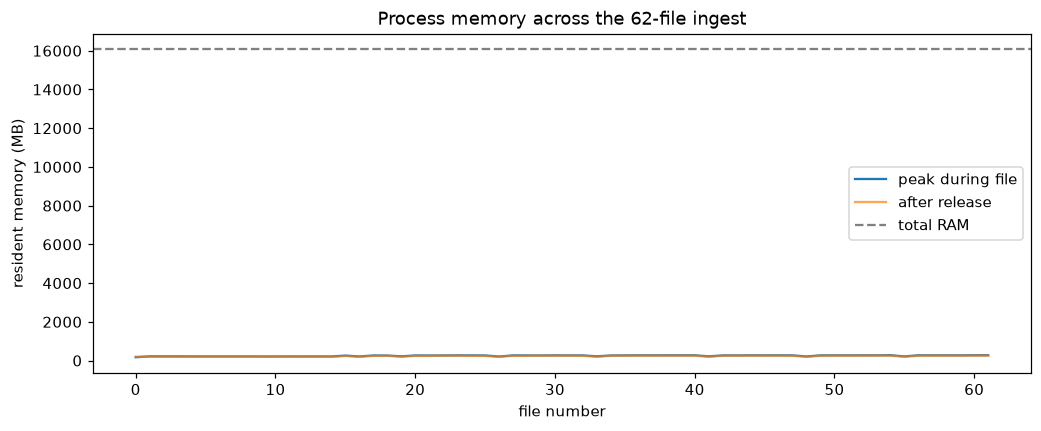

max peak: 276.8 MB
drift across run: 55.9 MB


In [9]:
PROFILE_PATH = TAB_DIR / "ingest_memory_profile.csv"

if peaks:
    prof = pd.DataFrame(peaks)
    prof.to_csv(PROFILE_PATH, index=False)
elif PROFILE_PATH.exists():
    prof = pd.read_csv(PROFILE_PATH)
    print("ingest was cached this run, profile reloaded from", PROFILE_PATH.name)
else:
    prof = None

if prof is not None:
    fig, ax = plt.subplots()
    ax.plot(prof.index, prof.rss_peak, label="peak during file")
    ax.plot(prof.index, prof.rss_after, label="after release", alpha=0.7)
    ax.axhline(env["total_ram_gb"] * 1024, ls="--", c="grey", label="total RAM")
    ax.set_xlabel("file number")
    ax.set_ylabel("resident memory (MB)")
    ax.set_title("Process memory across the 62-file ingest")
    ax.legend()
    fig.savefig(FIG_DIR / "memory_profile.png", bbox_inches="tight")
    plt.show()
    print("max peak:", round(prof.rss_peak.max(), 1), "MB")
    print("drift across run:", round(prof.rss_after.iloc[-1] - prof.rss_after.iloc[0], 1), "MB")
else:
    print("no profile available, clear data/work and rerun 1.6 to reprofile")

Peak stayed below 290 MB against 15.7 GB available. Memory climbed over the first thirty files as the allocator settled into a steady working set, then held roughly flat for the remainder, with a total drift from first file to last of about 55 MB. The important property is that the level is set by the size of a single day and does not grow with the number of files, so the same pipeline would process 620 files as comfortably as 62. All 62 days were ingested in a little over four minutes.

**1.8 Building the analysis array**

The 62 Parquet days collapse into one dense float32 array of shape (intervals, squares). Every later section reads this array and never touches a text file again.

In [10]:
MATRIX_PATH = WORK_DIR / "internet_matrix.npy"
INDEX_PATH  = WORK_DIR / "time_index.parquet"

parts = sorted(WORK_DIR.glob("sms-call-internet-mi-*.parquet"))
print("cached days:", len(parts))

if MATRIX_PATH.exists() and INDEX_PATH.exists():
    traffic = np.load(MATRIX_PATH)
    times = pd.read_parquet(INDEX_PATH)["timestamp"]
    print("loaded cached array")
else:
    stamps = set()
    for p in parts:
        stamps.update(pd.read_parquet(p, columns=["time_ms"])["time_ms"].unique().tolist())
    all_ms = np.array(sorted(stamps), dtype="int64")

    full_ms = np.arange(all_ms.min(), all_ms.max() + STEP_MS, STEP_MS, dtype="int64")
    ms_index = pd.Index(full_ms)
    traffic = np.full((len(full_ms), N_SQUARES), np.nan, dtype=np.float32)

    for p in parts:
        part = pd.read_parquet(p)
        row = ms_index.get_indexer(part["time_ms"].to_numpy())
        col = part["square_id"].to_numpy() - 1
        traffic[row, col] = part["internet"].to_numpy()
        del part

    times = (pd.to_datetime(full_ms, unit="ms", utc=True)
               .tz_convert(TZ).to_series(name="timestamp").reset_index(drop=True))
    np.save(MATRIX_PATH, traffic)
    times.to_frame().to_parquet(INDEX_PATH, index=False)
    gc.collect()

times = pd.DatetimeIndex(times)
print("array shape:", traffic.shape, traffic.dtype)
print("array size:", round(traffic.nbytes / 1024**2, 1), "MB")
print("span:", times[0], "to", times[-1])

cached days: 62
loaded cached array
array shape: (8928, 10000) float32
array size: 340.6 MB
span: 2013-11-01 00:00:00+01:00 to 2014-01-01 23:50:00+01:00


**Timezone note.** Raw timestamps are UTC. Milan is UTC+1 in November and December, so the first record at 23:00 UTC on 31 October is midnight on 1 November local. Without the conversion every daily-cycle result in Section 2 would be shifted by one hour.

**1.9 Missing values**

Gaps are counted before any are filled, and the filling rule is stated rather than applied silently.

In [11]:
n_missing = int(np.isnan(traffic).sum())
print(f"missing cells: {n_missing:,} of {traffic.size:,} ({100 * n_missing / traffic.size:.4f}%)")

per_step = np.isnan(traffic).sum(axis=1)
print("intervals with any gap:", int((per_step > 0).sum()), "of", len(per_step))
print("worst interval:", int(per_step.max()), "squares missing")

gap_runs = pd.Series(np.isnan(traffic).sum(axis=0))
print("squares with at least one gap:", int((gap_runs > 0).sum()))
print("max gaps in a single square:", int(gap_runs.max()))

missing cells: 152,527 of 89,280,000 (0.1708%)
intervals with any gap: 8224 of 8928
worst interval: 67 squares missing
squares with at least one gap: 98
max gaps in a single square: 8186


In [12]:
def fill_series(values):
    s = pd.Series(values.astype("float64"))
    s = s.interpolate(limit_direction="both", limit_area="inside")
    return s.fillna(0.0).to_numpy(dtype="float32")

print("policy: linear interpolation across isolated interior gaps, zero outside.")
print("applied per square at the point of use, not to the stored array.")

policy: linear interpolation across isolated interior gaps, zero outside.
applied per square at the point of use, not to the stored array.


Gaps are 0.17% of cells, but they are concentrated rather than scattered. Only 98 of 10,000 squares are affected and one is missing 8,186 of 8,928 intervals, so roughly 17 squares' worth of data comes from squares that barely reported at all. Linear interpolation is defensible across an isolated interval and would be fabrication across a two-month outage, so the policy is applied per series at the point of use rather than to the stored array, and the gap counts are reported before any filling. The target areas are checked individually once Section 2 identifies them.

In [13]:
gaps_per_square = np.isnan(traffic).sum(axis=0)

print("squares more than half missing:", int((gaps_per_square > len(times) // 2).sum()))
print("squares with any gap:", int((gaps_per_square > 0).sum()))
print("worst single square:", int(gaps_per_square.max()), "missing of", len(times))
for sq in (4159, 4556):
    print(f"square {sq:>5}: {int(gaps_per_square[sq - 1]):>5} missing of {len(times)}")
print("\nthe three highest-traffic areas are checked in Section 2.2 once identified")

squares more than half missing: 6
squares with any gap: 98
worst single square: 8186 missing of 8928
square  4159:     0 missing of 8928
square  4556:     0 missing of 8928

the three highest-traffic areas are checked in Section 2.2 once identified


**1.10 Summary of the reduction**

In [14]:
raw_gb   = sum(f.stat().st_size for f in raw_files) / 1024**3
cache_gb = sum(f.stat().st_size for f in parts) / 1024**3
array_gb = traffic.nbytes / 1024**3

evidence = pd.DataFrame(mem_log)

evidence["frame_vs_naive_%"] = (100 * (1 - evidence.frame_mb / baseline["frame_mb"])).round(1)
evidence["peak_vs_naive_%"]  = (100 * (1 - evidence.peak_delta_mb / baseline["peak_delta_mb"])).round(1)
display(evidence[["stage", "rows", "frame_mb", "rss_before_mb", "peak_delta_mb", "rss_held_mb",
                  "frame_vs_naive_%", "peak_vs_naive_%", "seconds"]])
evidence.to_csv(TAB_DIR / "memory_evidence.csv", index=False)

,stage,rows,frame_mb,rss_before_mb,peak_delta_mb,rss_held_mb,frame_vs_naive_%,peak_vs_naive_%,seconds
0,"naive read, all columns",4842625,295.6,128.9,316.4,298.5,0.0,0.0,3.30
1,"typed read, internet only",4842625,73.9,131.9,106.1,73.7,75.0,66.5,2.69
2,aggregated over country,1439982,19.2,205.5,241.9,20.3,93.5,23.5,0.47
3,"aggregated, sort=False",1439982,19.2,225.4,200.9,19.6,93.5,36.5,0.29


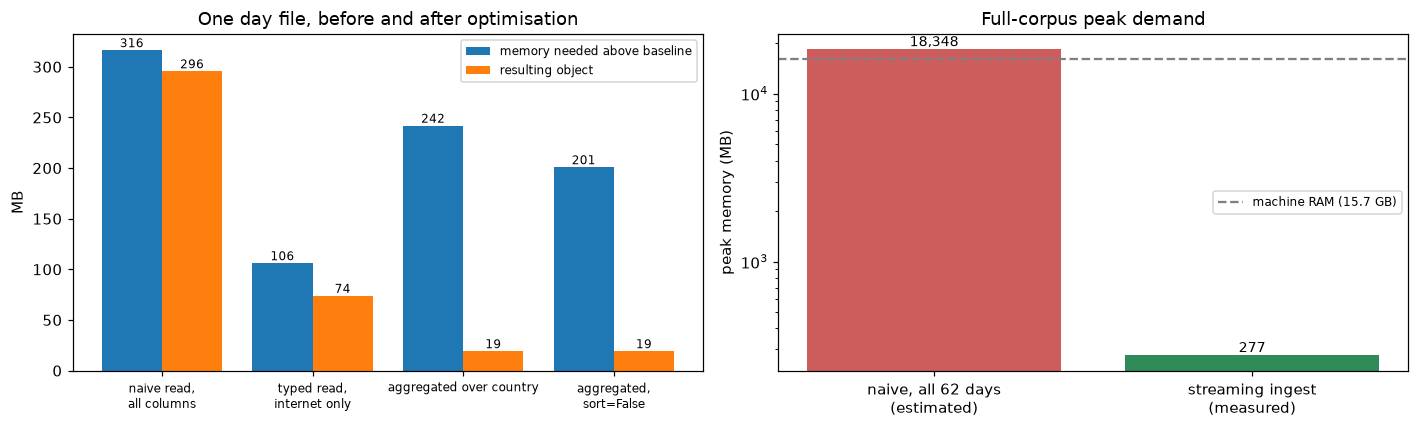

In [15]:
short = [s.replace(", ", ",\n") for s in evidence.stage]
peak_col = "peak_delta_mb" if "peak_delta_mb" in evidence else "rss_peak_mb"
x = np.arange(len(evidence))
ram_mb = env["total_ram_gb"] * 1024

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(x - 0.2, evidence[peak_col], 0.4, label="memory needed above baseline")
ax[0].bar(x + 0.2, evidence.frame_mb, 0.4, label="resulting object")
ax[0].set_xticks(x)
ax[0].set_xticklabels(short, fontsize=8)
ax[0].set_ylabel("MB")
ax[0].set_title("One day file, before and after optimisation")
ax[0].legend(fontsize=8)
for xi, (pk, fr) in enumerate(zip(evidence[peak_col], evidence.frame_mb)):
    ax[0].text(xi - 0.2, pk, f"{pk:.0f}", ha="center", va="bottom", fontsize=8)
    ax[0].text(xi + 0.2, fr, f"{fr:.0f}", ha="center", va="bottom", fontsize=8)

actual_peak = prof.rss_peak.max() if prof is not None else np.nan
bars = ["naive, all 62 days\n(estimated)", "streaming ingest\n(measured)"]
vals = [naive_peak_estimate * 1024, actual_peak]
ax[1].bar(bars, vals, color=["indianred", "seagreen"])
ax[1].axhline(ram_mb, ls="--", c="grey", label=f"machine RAM ({env['total_ram_gb']} GB)")
ax[1].set_ylabel("peak memory (MB)")
ax[1].set_yscale("log")
ax[1].set_title("Full-corpus peak demand")
ax[1].legend(fontsize=8)
for xi, v in enumerate(vals):
    if not np.isnan(v):
        ax[1].text(xi, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "memory_before_after.png", bbox_inches="tight")
plt.show()

In [16]:
footprint = pd.DataFrame([
    ["raw text on disk", raw_gb * 1024, "62 tab separated files"],
    ["parquet cache on disk", cache_gb * 1024, "aggregated, snappy compressed"],
    ["analysis array in memory", array_gb * 1024, f"float32 {traffic.shape}"],
], columns=["artefact", "size_mb", "note"])
footprint["size_mb"] = footprint["size_mb"].round(1)
footprint["vs_raw_%"] = (100 * (1 - footprint.size_mb / footprint.size_mb.iloc[0])).round(1)
display(footprint)
footprint.to_csv(TAB_DIR / "disk_footprint.csv", index=False)

print(f"disk footprint reduced {raw_gb / array_gb:.0f}x, "
      f"from {raw_gb:.1f} GB to {array_gb * 1024:.0f} MB")
print(f"naive peak demand for the full corpus: ~{naive_peak_estimate:.1f} GB")
print(f"measured peak of the streaming ingest:  "
      f"{prof.rss_peak.max() / 1024:.2f} GB" if prof is not None else "(no ingest profile)")

,artefact,size_mb,note,vs_raw_%
0,raw text on disk,19841.0,62 tab separated files,0.0
1,parquet cache on disk,407.9,"aggregated, snappy compressed",97.9
2,analysis array in memory,340.6,"float32 (8928, 10000)",98.3


disk footprint reduced 58x, from 19.4 GB to 341 MB
naive peak demand for the full corpus: ~17.9 GB
measured peak of the streaming ingest:  0.27 GB


**Discussion**

Three changes did the work, in increasing order of effect. Narrower dtypes halved the per-row cost. Dropping the four unused activity columns at parse time avoided converting values that were never going to be read. Aggregating over country code before writing removed roughly two thirds of the rows, because a single square and interval is recorded once per counterparty nation.

Processing one file at a time is what makes the whole thing fit. Peak memory is bounded by the largest single day rather than by the corpus, which is why the profile in 1.7 plateaus rather than climbing with file count.

**Trade-offs.** float32 loses precision relative to float64; the activity values have narrow dynamic range so the loss sits far below measurement noise, but this would be the wrong choice for a dataset with a wider range. Summing over country code discards the origin-nation dimension permanently, which forecloses any analysis of foreign versus domestic traffic. Dropping the SMS and call columns rules out multivariate extensions without re-running the ingest. Parquet adds a dependency and a one-off conversion cost that is repaid on every later read.

Approach informed by the pandas documentation on dtype selection and memory usage (McKinney, 2010) and by the Apache Parquet columnar format specification. The dataset's own data descriptor recommends pandas for working with these files (Barlacchi et al., 2015, Usage Notes).

# 2. Exploratory Analysis

The purpose is to establish what the forecasting models will have to cope with: how traffic is spread across the city, what the temporal structure of a busy area looks like, and which lags carry information.

**2.1 Distribution of total traffic across the 10,000 areas**

Total internet activity is summed over the whole two months for each square, then examined on a log axis because the spread is expected to cover several orders of magnitude.

In [ ]:
totals = np.nansum(traffic, axis=0) # Total internet activity per square, ignoring NaNs. This sums the traffic for each square across all time intervals.
order = np.argsort(totals)[::-1]

pd.set_option("display.float_format", "{:.2f}".format)

desc = pd.Series(totals).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])
display(desc.to_frame("total_internet_activity"))

share = np.cumsum(totals[order]) / totals.sum()
for k in (10, 100, 500, 1000):
    print(f"top {k:>5} squares ({k/100:>4.0f}% of grid) carry {100*share[k-1]:5.1f}% of all traffic")
print(f"\nmax / median ratio: {totals.max() / np.median(totals):.0f}x")
print(f"spread: {np.log10(totals.max() / totals.min()):.1f} orders of magnitude")

,total_internet_activity
count,10000.00
mean,555289.38
std,892595.81
min,213.63
25%,118101.96
50%,277871.39
75%,577894.80
90%,1243960.83
99%,4698735.44
max,12740067.00


top    10 squares (   0% of grid) carry   1.7% of all traffic
top   100 squares (   1% of grid) carry  11.0% of all traffic
top   500 squares (   5% of grid) carry  33.6% of all traffic
top  1000 squares (  10% of grid) carry  48.4% of all traffic

max / median ratio: 46x
spread: 4.8 orders of magnitude


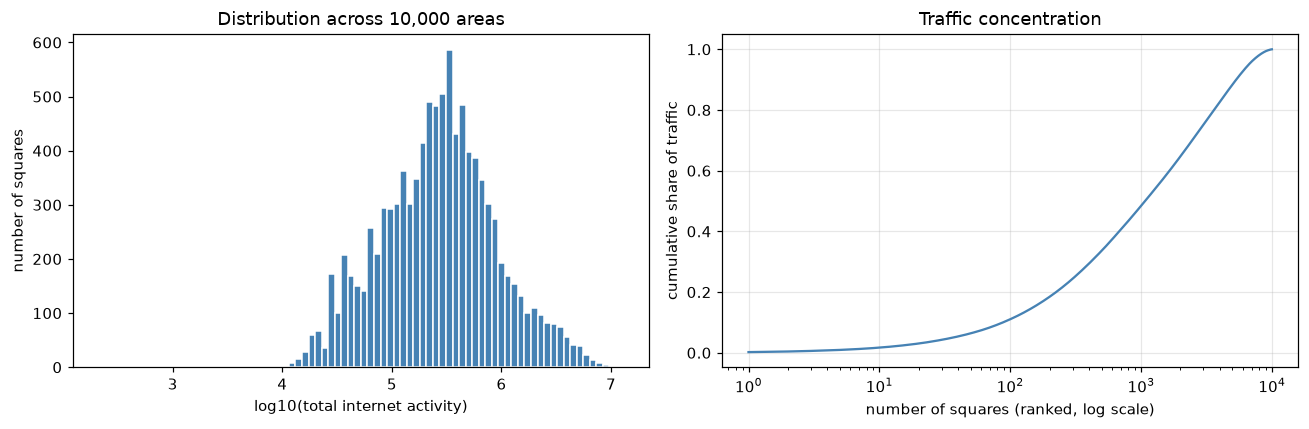

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(np.log10(totals[totals > 0]), bins=80, color="steelblue", edgecolor="white")
ax[0].set_xlabel("log10(total internet activity)")
ax[0].set_ylabel("number of squares")
ax[0].set_title("Distribution across 10,000 areas")

ax[1].plot(np.arange(1, N_SQUARES + 1), share, color="steelblue")
ax[1].set_xscale("log")
ax[1].set_xlabel("number of squares (ranked, log scale)")
ax[1].set_ylabel("cumulative share of traffic")
ax[1].set_title("Traffic concentration")
ax[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "traffic_distribution.png", bbox_inches="tight")
plt.show()

Discussion

The distribution is right skewed across 4.8 orders of magnitude, from a minimum of 214 to a maximum of 12,740,067, with a median of 277,871 and a mean of 555,289. Mean well above median with a standard deviation of 892,596 confirms a long right tail rather than a symmetric spread. The busiest square carries 46 times the median. The top 1% of squares carry 11.0% of all traffic, the top 5% carry 33.6%, and the top 10% carry 48.4%, so roughly half the city's traffic passes through a tenth of its area.

Two consequences for the modelling. First, absolute error is not comparable across areas, so the comparison in Section 4 has to be read per area rather than pooled, and each series is normalised using its own training statistics. Second, a model tuned on a central high-volume square is being tuned on a different signal-to-noise regime than a quiet suburban one, which is exactly what the second half of the research question asks about.

**2.2 The three busiest areas, plus squares 4159 and 4556**

Five series are plotted over the first two weeks: the top three by total volume, and the two squares named in the brief.

In [19]:
top3 = (order[:3] + 1).tolist()
focus = top3 + [4159, 4556]
print("top 3 squares by total internet activity:", top3)
for sq in focus:
    t = totals[sq - 1]
    rank = int(np.where(order + 1 == sq)[0][0]) + 1
    print(f"square {sq:>5}: total {t:14,.0f}   rank {rank:>5} of {N_SQUARES}")

print("\nmissing-interval check for the five areas used below:")
for sq in focus:
    print(f"square {sq:>5}: {int(gaps_per_square[sq - 1]):>5} missing of {len(times)}")

top 3 squares by total internet activity: [5161, 5059, 5259]
square  5161: total     12,740,067   rank     1 of 10000
square  5059: total     11,170,842   rank     2 of 10000
square  5259: total     10,485,784   rank     3 of 10000
square  4159: total      2,454,137   rank   424 of 10000
square  4556: total      4,574,661   rank   109 of 10000

missing-interval check for the five areas used below:
square  5161:     0 missing of 8928
square  5059:     0 missing of 8928
square  5259:     0 missing of 8928
square  4159:     0 missing of 8928
square  4556:     0 missing of 8928


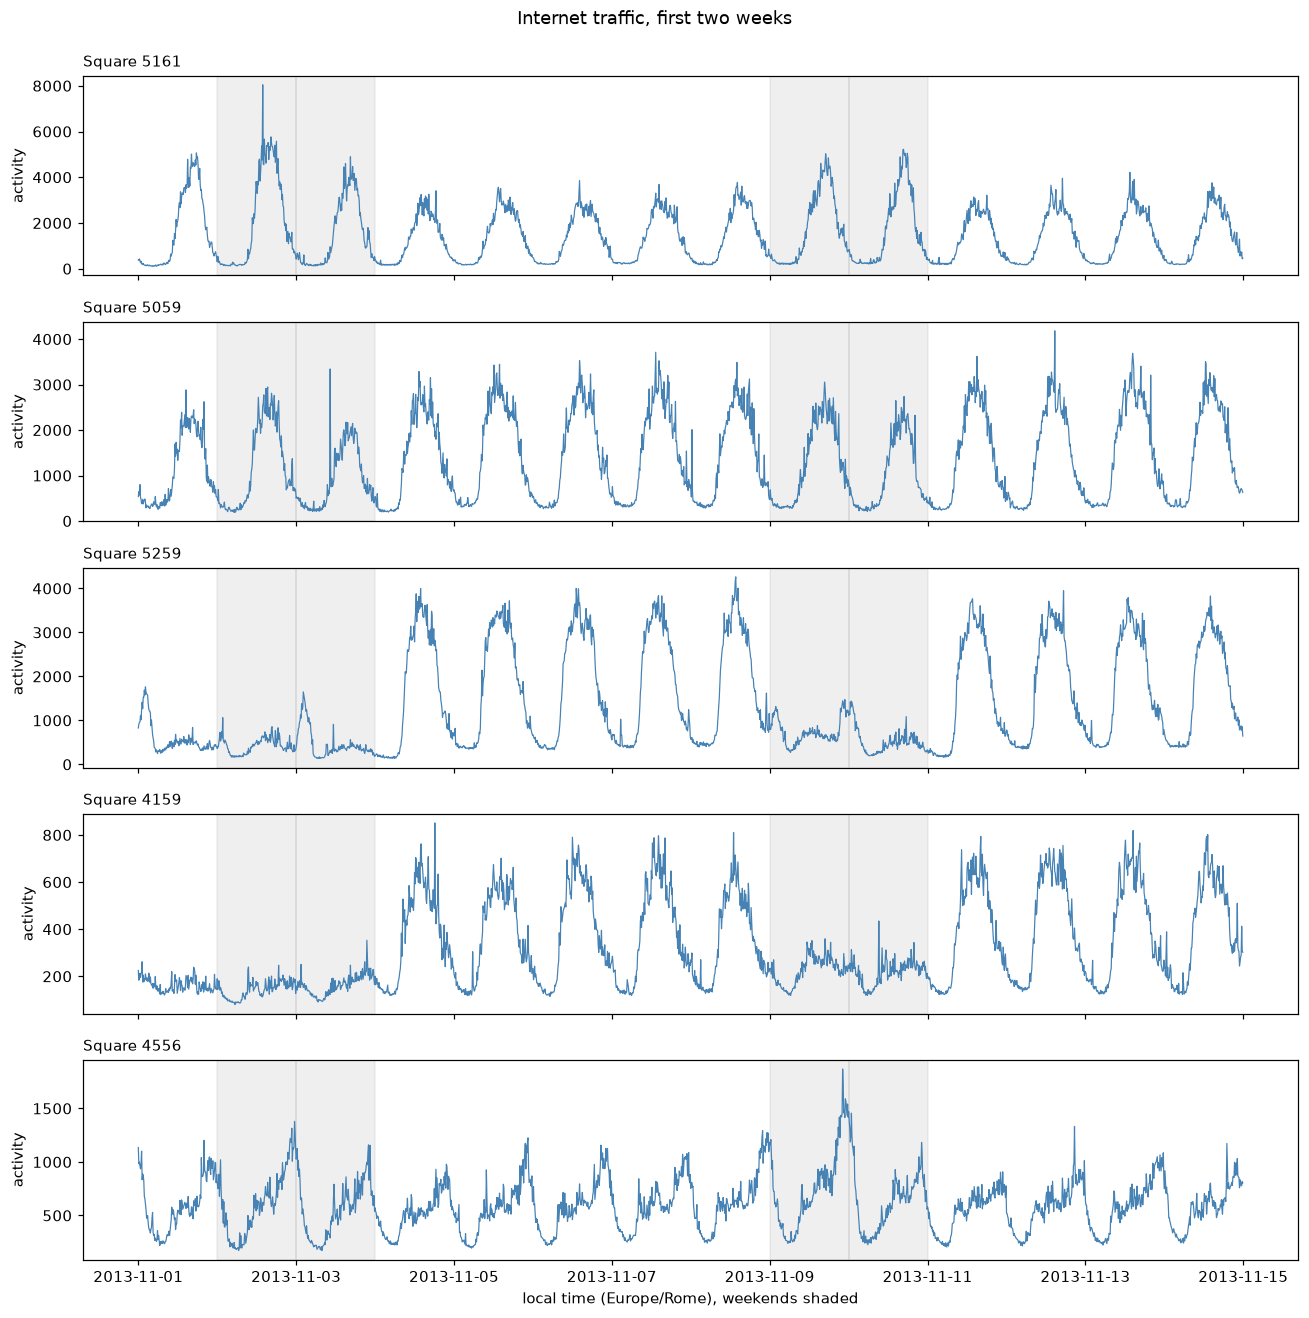

In [20]:
two_weeks = (times >= times[0]) & (times < times[0] + pd.Timedelta(days=14))
idx = times[two_weeks]

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
for ax, sq in zip(axes, focus):
    series = fill_series(traffic[two_weeks, sq - 1])
    ax.plot(idx, series, lw=0.8, color="steelblue")
    ax.set_ylabel("activity")
    ax.set_title(f"Square {sq}", loc="left", fontsize=10)
    for day in pd.date_range(idx[0], idx[-1], freq="D"):
        if day.dayofweek >= 5:
            ax.axvspan(day, day + pd.Timedelta(days=1), color="grey", alpha=0.12)
axes[-1].set_xlabel("local time (Europe/Rome), weekends shaded")
fig.suptitle("Internet traffic, first two weeks", y=0.995)
fig.tight_layout()
fig.savefig(FIG_DIR / "five_areas_two_weeks.png", bbox_inches="tight")
plt.show()

In [21]:
rows = []
for sq in focus:
    s = pd.Series(fill_series(traffic[two_weeks, sq - 1]), index=idx)
    wk = s[s.index.dayofweek < 5]
    we = s[s.index.dayofweek >= 5]
    rows.append({
        "square": sq,
        "mean": s.mean(),
        "std": s.std(),
        "cv": s.std() / s.mean(),
        "peak_hour": int(s.groupby(s.index.hour).mean().idxmax()),
        "trough_hour": int(s.groupby(s.index.hour).mean().idxmin()),
        "weekend_vs_weekday": we.mean() / wk.mean(),
        "max_over_median": s.max() / s.median(),
    })
profile = pd.DataFrame(rows).set_index("square").round(2)
display(profile)
profile.to_csv(TAB_DIR / "area_profiles.csv")

,mean,std,cv,peak_hour,trough_hour,weekend_vs_weekday,max_over_median
square,,,,,,,
5161,1483.55,1312.80,0.88,16,5,1.26,7.26
5059,1330.62,952.40,0.72,14,4,0.77,3.88
5259,1293.50,1136.68,0.88,13,6,0.34,6.03
4159,311.35,189.26,0.61,12,5,0.52,3.63
4556,592.70,255.60,0.43,22,5,1.11,3.21


Discussion

All five share a daily cycle with an overnight trough between 04:00 and 06:00 and a daytime plateau, and all five show a weekday-weekend amplitude difference, so seasonality at a period of 144 intervals is common to the city rather than local to one cell.

The differences are in level, in the coefficient of variation, and in the weekend ratio, and they are interpretable as human behaviour. Squares 5161 and 5259 are the most variable at a coefficient of variation of 0.88; square 4556 is the flattest at 0.43.

Square 5259 retains only 34% of its weekday level at weekends and peaks at 13:00, which is the signature of a workplace or office district emptying on Saturday and Sunday. Square 4556 is the opposite: it peaks at 22:00, the only one of the five to peak at night, and is 11% busier at weekends, which fits residential or nightlife use. Square 5161 peaks at 16:00 and is 26% busier at weekends, consistent with a central mixed-use area. Square 5161 also has the largest ratio of maximum to median at 7.26, so it is the burstiest of the five.

The missing-value counts in Section 1.9 confirm all five areas have complete coverage, 0 missing intervals of 8,928, so none of these patterns is a reporting artefact.

**2.3 First additional analysis: decomposition and stationarity**

Run on the busiest square. The question is whether the series can be treated as stationary, and if not, what has to be removed first.

series length: 8928  from 2013-11-01 00:00:00+01:00 to 2014-01-01 23:50:00+01:00


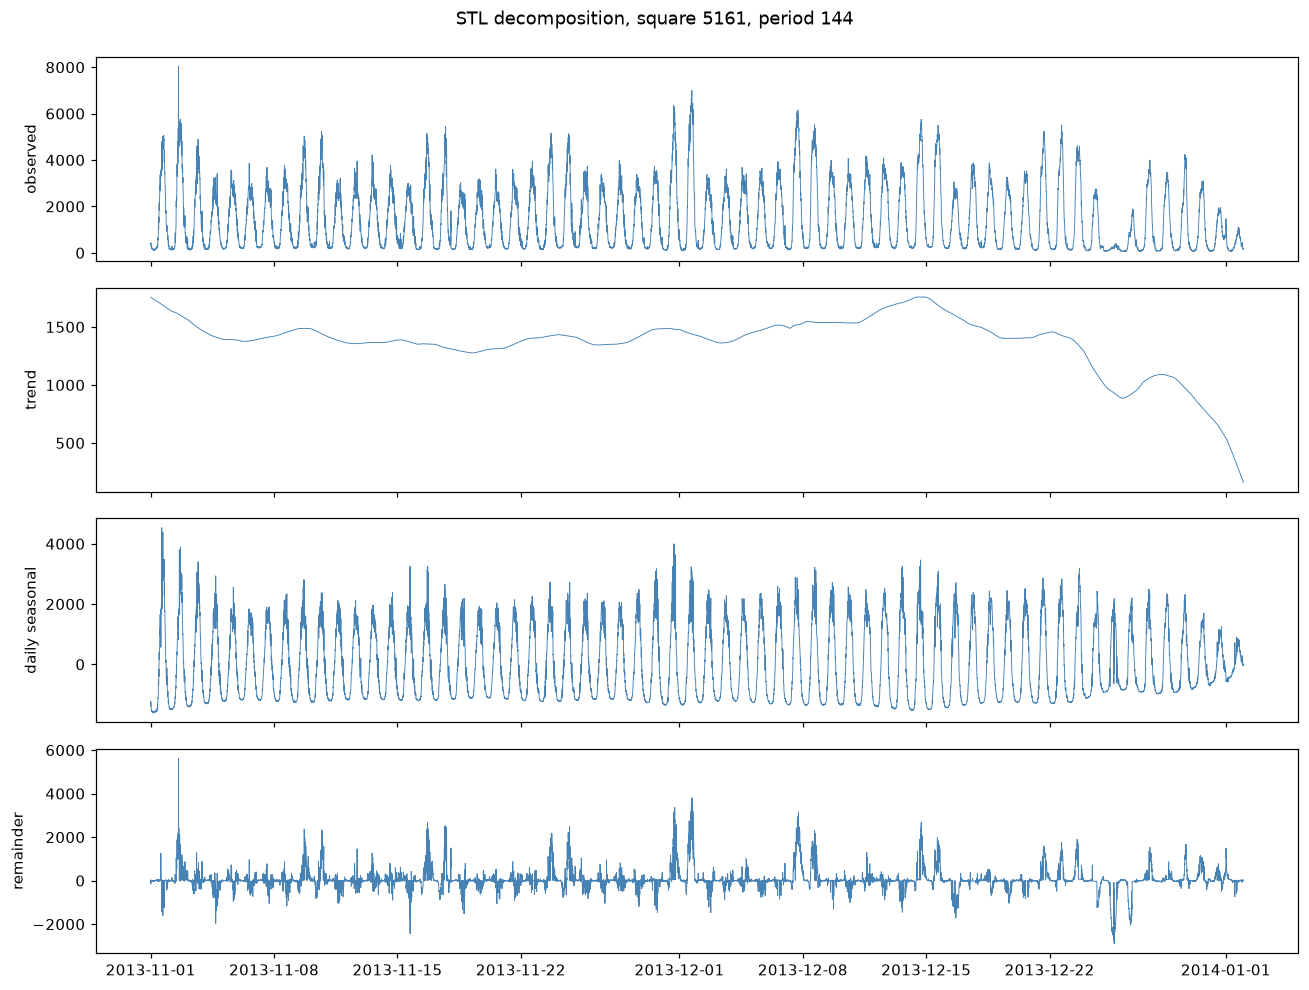

seasonal share of variance:  0.77
trend share of variance:     0.03
remainder share of variance: 0.14


In [22]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

target_sq = top3[0]
y = pd.Series(fill_series(traffic[:, target_sq - 1]), index=times, name=f"square_{target_sq}")
print("series length:", len(y), " from", y.index[0], "to", y.index[-1])

stl = STL(y, period=STEPS_PER_DAY, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, (comp, label) in zip(axes, [(y, "observed"), (stl.trend, "trend"),
                                    (stl.seasonal, "daily seasonal"), (stl.resid, "remainder")]):
    ax.plot(y.index, comp, lw=0.6, color="steelblue")
    ax.set_ylabel(label)
fig.suptitle(f"STL decomposition, square {target_sq}, period 144", y=0.995)
fig.tight_layout()
fig.savefig(FIG_DIR / "stl_decomposition.png", bbox_inches="tight")
plt.show()

var_total = y.var()
print(f"seasonal share of variance:  {stl.seasonal.var() / var_total:.2f}")
print(f"trend share of variance:     {stl.trend.var() / var_total:.2f}")
print(f"remainder share of variance: {stl.resid.var() / var_total:.2f}")

In [23]:
def stationarity(series, label):
    adf_stat, adf_p = adfuller(series, autolag="AIC")[:2]
    kpss_stat, kpss_p = kpss(series, regression="c", nlags="auto")[:2]
    print(f"{label:28s} ADF p={adf_p:.4f}   KPSS p={kpss_p:.4f}")
    return {"series": label, "adf_p": adf_p, "kpss_p": kpss_p}

tests = [
    stationarity(y, "raw"),
    stationarity(np.log1p(y), "log1p"),
    stationarity(np.log1p(y).diff(STEPS_PER_DAY).dropna(), "log1p, seasonal diff 144"),
    stationarity(np.log1p(y).diff().dropna(), "log1p, first diff"),
]
pd.DataFrame(tests).round(4).to_csv(TAB_DIR / "stationarity_tests.csv", index=False)
display(pd.DataFrame(tests).round(4))

C:\Users\cyuba\AppData\Local\Temp\ipykernel_16448\2426239190.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_p = kpss(series, regression="c", nlags="auto")[:2]


raw                          ADF p=0.0000   KPSS p=0.1000
log1p                        ADF p=0.0000   KPSS p=0.0257


C:\Users\cyuba\AppData\Local\Temp\ipykernel_16448\2426239190.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_p = kpss(series, regression="c", nlags="auto")[:2]


log1p, seasonal diff 144     ADF p=0.0000   KPSS p=0.1000
log1p, first diff            ADF p=0.0000   KPSS p=0.1000


C:\Users\cyuba\AppData\Local\Temp\ipykernel_16448\2426239190.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_p = kpss(series, regression="c", nlags="auto")[:2]


,series,adf_p,kpss_p
0,raw,0.00,0.10
1,log1p,0.00,0.03
2,"log1p, seasonal diff 144",0.00,0.10
3,"log1p, first diff",0.00,0.10


Discussion

The decomposition attributes 77% of variance to the daily seasonal component against 3% for trend and 14% for the remainder, confirming that the dominant structure is periodic rather than trending. Whatever a model learns here, it is mostly learning time of day.

The two tests answer different questions and are read together. ADF tests against a unit root; KPSS tests against a stationary null. On the raw series ADF gives p = 0.0000 and KPSS gives p = 0.1000, so both agree the series is stationary in the weak sense: it is a bounded periodic signal with no random walk component. This is worth stating explicitly, because strong seasonality is often mistaken for non-stationarity and the two are distinct properties.

The one configuration the tests disagree about is log1p alone, where KPSS falls to p = 0.0257. Seasonal differencing at lag 144 restores agreement at p = 0.1000. Differencing is therefore applied before the ARIMA not to remove a unit root, which is absent, but to remove the deterministic daily cycle that a linear autoregressive model cannot otherwise represent. The log1p transform is retained for all three models because it stabilises variance that would otherwise scale with the level, as the skew in Section 2.1 implies.

One caveat on the numbers: statsmodels reports p = 0.1000 for KPSS whenever the statistic falls outside its lookup table, which happened in three of the four cases. That value is a floor, not a point estimate, and the true p-value is higher.

**2.4 Second additional analysis: autocorrelation**

This is what sets the input window length. If information sits at lag 144, the models need to see at least a day.

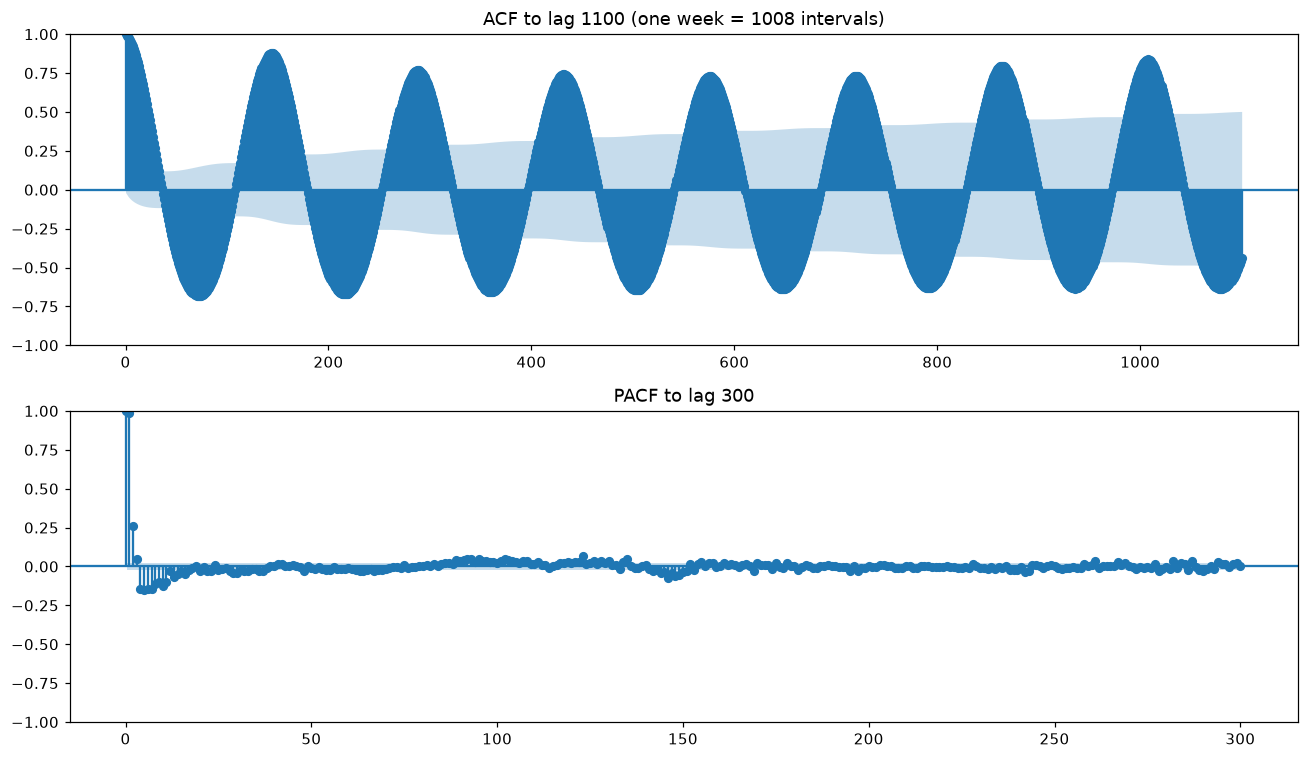

lag     1 ( 10 min): acf =  0.987
lag     6 ( 1 hour): acf =  0.939
lag   144 (  1 day): acf =  0.878
lag   288 ( 2 days): acf =  0.770
lag  1008 ( 1 week): acf =  0.838


In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(y, lags=1100, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF to lag 1100 (one week = 1008 intervals)")
plot_pacf(y, lags=300, ax=axes[1], method="ywm", alpha=0.05)
axes[1].set_title("PACF to lag 300")
fig.tight_layout()
fig.savefig(FIG_DIR / "acf_pacf.png", bbox_inches="tight")
plt.show()

a = acf(y, nlags=1100, fft=True)
for lag, label in [(1, "10 min"), (6, "1 hour"), (144, "1 day"), (288, "2 days"), (1008, "1 week")]:
    print(f"lag {lag:>5} ({label:>7}): acf = {a[lag]: .3f}")

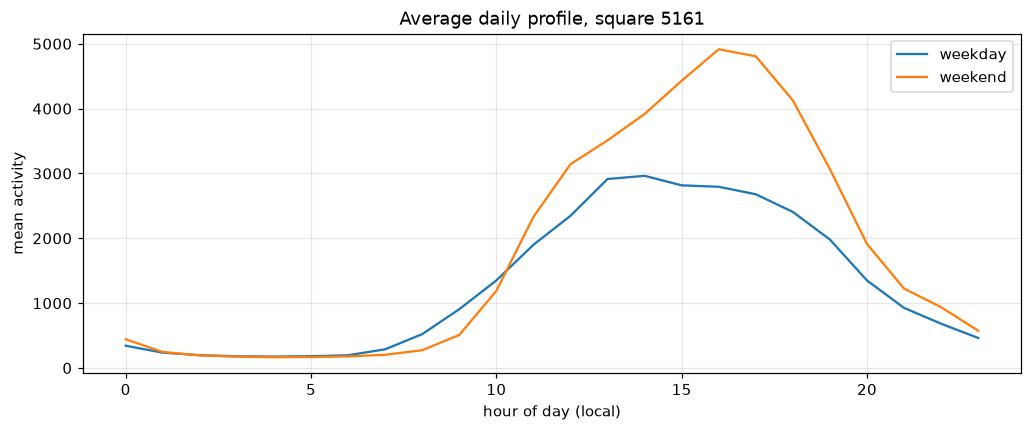

weekday peak hour: 14  weekend peak hour: 16
weekend / weekday mean ratio: 1.384


In [25]:
by_hour = y.groupby([y.index.dayofweek >= 5, y.index.hour]).mean().unstack(0)
by_hour.columns = ["weekday", "weekend"]

fig, ax = plt.subplots()
by_hour.plot(ax=ax)
ax.set_xlabel("hour of day (local)")
ax.set_ylabel("mean activity")
ax.set_title(f"Average daily profile, square {target_sq}")
ax.grid(alpha=0.3)
fig.savefig(FIG_DIR / "daily_profile.png", bbox_inches="tight")
plt.show()

print("weekday peak hour:", int(by_hour.weekday.idxmax()),
      " weekend peak hour:", int(by_hour.weekend.idxmax()))
print("weekend / weekday mean ratio:", round(by_hour.weekend.mean() / by_hour.weekday.mean(), 3))

Discussion

Autocorrelation at lag 1 is 0.987, so the immediately preceding interval is by far the strongest single predictor. Dependence decays with distance, 0.939 at one hour and 0.770 at two days, but recovers at structural lags: 0.878 at one day and 0.838 at one week. The weekly lag exceeding the two-day lag is the important detail, because simple decay cannot produce that inversion. It is the weekly rhythm asserting itself, and it corroborates the weekday and weekend differences in Section 2.2.

The daily profile makes the same point from a different angle. The weekday peak sits at 14:00 and the weekend peak at 16:00, and the weekend mean is 1.384 times the weekday mean for this square, so the shape of a day depends on which day it is.

Two decisions follow directly. The input window is set to 144 intervals, one full day, because that is the shortest window containing both the short-range dependence and one complete period of the dominant seasonality. Extending to a week would multiply the parameter count and training time for the smaller weekly signal, which is a trade-off worth naming rather than assuming away.

The PACF cuts off after a small number of lags once seasonality is accounted for, which bounds the autoregressive order searched for the ARIMA in Section 4 to single digits.

The PACF confirms this: after a spike at lag 1 and a value near 0.26 at lag 2, it falls to a small negative tail through lags 3 to 10 and is indistinguishable from zero beyond lag 15. Three autoregressive terms are therefore sufficient, which is the bound used for the ARIMA order grid in Section 4.5.

# 3. Related Work and Model Selection

The three models are chosen from three different families so that the comparison tests an idea about inductive bias rather than a difference in hyperparameters.

**3.1 What the literature reports on this problem**

Work on this dataset and on comparable cellular traffic falls into three groups.

Classical statistical forecasting is the long-standing baseline. Azari et al. [4] compare LSTM against ARIMA on real cellular traffic and report that the recurrent model is generally better, but explicitly conditional on the training series being long enough and the sampling granularity fine enough. That conditional matters here: the setup in Section 4 has about 5,500 training intervals at 10-minute resolution, which sits inside the regime where their result predicts the neural model should win. If it does not, that is a finding rather than a bug.

Recurrent deep learning is the dominant approach in recent work. A study on this same Milan dataset compared LSTM and GRU after clustering cells by activity level and tuning each by grid search, and found that relative performance varied across clusters within the city [5]. That is direct precedent for the second half of the research question. A broader study on the Telecom Italia data built eight models including SARIMA, Prophet, AdaBoost, XGBoost, LSTM, CNN and hybrid CNN-LSTM [6], which places the three chosen here inside a wider field rather than presenting them as the only options.

Convolutional sequence modelling is the third group. Bai, Kolter and Koltun [7] evaluate generic convolutional and recurrent architectures across sequence tasks and argue that the common association between sequence modelling and recurrent networks should be reconsidered, with convolutions a reasonable default starting point. A causal 1D convolution with dilation gives an input window whose size is set explicitly by the architecture rather than learned, which is directly testable against the lag structure found in Section 2.4.

A fourth group models the city as a spatial grid. Zhang and Patras [8] propose a spatio-temporal network that forecasts all locations jointly and exploits correlation between neighbouring cells. That approach is deliberately not taken here. The brief specifies one-step-ahead forecasting for a single geographical area at a time, so the spatial dimension is outside the scope of the stated question. It is recorded in Section 6 as the most obvious extension.

**3.2 The three selected models**

**ARIMA.** A linear model of the series in terms of its own past values and past errors. Selected as the statistical reference point because Section 2.3 showed the series becomes stationary after seasonal differencing at lag 144, which is precisely the condition under which ARIMA is applicable. Its strength is that it is fully interpretable and has few parameters, so it cannot overfit 5,500 points. Its limitation is structural: it is linear, so it cannot represent the burst behaviour visible in the two-week plots, and it assumes the relationship between lags is fixed over time. Applied to the seasonally differenced log series rather than a full seasonal ARIMA, because a seasonal order at period 144 is computationally impractical to estimate on this series length.

**LSTM.** A gated recurrent network that maintains a cell state across the input window. Selected because the strongest reported results on this dataset come from recurrent models [4] [5], and because gating is the mechanism that allows information from the start of a 144-step window to reach the output without vanishing. Its limitation is that it is sequential over time steps, so training does not parallelise across the window, and it has enough parameters to overfit a single univariate series without early stopping.

**1D CNN with causal dilated convolutions.** Stacked convolutions with dilation rates 1, 2, 4, 8, 16, 32 give a receptive field of 127 intervals, covering most of the 144-step window while keeping the depth small. Selected because it addresses the same dependency range as the LSTM through a completely different mechanism: a fixed, explicitly sized window rather than a learned recurrent state. Causal padding prevents any leakage from future intervals. Its strength is that the whole window is processed in parallel, so it should train faster. Its limitation is that the receptive field is a design constant, so anything beyond 127 intervals is invisible to it regardless of how much data it sees.

**Why not GRU as a fourth.** A GRU is a gated recurrent network differing from an LSTM by one gate, so it belongs to the same family and would not add a genuinely different comparison. It is run in Section 4.7 as a tuning comparison against the LSTM instead.

**Reference line.** A seasonal-naive predictor, which forecasts each interval as the value observed at the same time on the previous day. It is not one of the three models. It exists so that the reported errors can be read as an improvement over a rule that requires no fitting at all.

# 4. Forecasting Experiments

**4.1 Problem setup**

Let `x_a(t)` be the aggregated internet activity in area `a` during 10-minute interval `t`. At each step the model receives the window `[x_a(t-143), ..., x_a(t)]` and produces a single estimate of `x_a(t+1)`. Forecasting is one step ahead throughout: true history is supplied at every step, no prediction is ever fed back as input.

Evaluation covers the week of 16 to 22 December, which is 1,008 consecutive one-step forecasts per model per area.

In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

WINDOW = 144

TRAIN_END = pd.Timestamp("2013-12-09 00:00", tz=TZ)
VAL_END   = pd.Timestamp("2013-12-16 00:00", tz=TZ)
TEST_END  = pd.Timestamp("2013-12-23 00:00", tz=TZ)

is_train = times < TRAIN_END
is_val   = (times >= TRAIN_END) & (times < VAL_END)
is_test  = (times >= VAL_END) & (times < TEST_END)

print(f"train {is_train.sum():>5} intervals  {times[is_train][0]} to {times[is_train][-1]}")
print(f"val   {is_val.sum():>5} intervals  {times[is_val][0]} to {times[is_val][-1]}")
print(f"test  {is_test.sum():>5} intervals  {times[is_test][0]} to {times[is_test][-1]}")
print("\ntest week starts on a", times[is_test][0].day_name())

train  5472 intervals  2013-11-01 00:00:00+01:00 to 2013-12-08 23:50:00+01:00
val    1008 intervals  2013-12-09 00:00:00+01:00 to 2013-12-15 23:50:00+01:00
test   1008 intervals  2013-12-16 00:00:00+01:00 to 2013-12-22 23:50:00+01:00

test week starts on a Monday


Determinism is switched on deliberately. Without it, two runs of the same
configuration on a multi-core CPU return different validation errors, which
would make the one-change-at-a-time comparisons in 4.7 to 4.10 meaningless.
It costs some speed and that is the right trade here.

Validation is the week before the test week rather than a random sample, so tuning decisions are made on data that sits in the same temporal position relative to training as the test set does.

**4.2 Input representation and preprocessing**

Identical for all three models so that any difference in results comes from the model and not from the data it sees.

Steps: interpolate isolated gaps, apply `log1p` to stabilise variance, standardise using the mean and standard deviation of the training portion only, then cut overlapping windows of 144 steps. Predictions are inverted back to the original scale before any metric is computed.

In [27]:
def prepare(square_id):
    raw = fill_series(traffic[:, square_id - 1])
    logged = np.log1p(raw)
    mu = logged[is_train].mean()
    sd = logged[is_train].std()
    scaled = (logged - mu) / sd
    return raw, scaled, mu, sd

def invert(scaled_values, mu, sd):
    return np.expm1(scaled_values * sd + mu)

def make_windows(scaled):
    X = np.lib.stride_tricks.sliding_window_view(scaled, WINDOW)[:-1]
    y = scaled[WINDOW:]
    target_pos = np.arange(WINDOW, len(scaled))
    return X.astype("float32"), y.astype("float32"), target_pos

raw0, scaled0, mu0, sd0 = prepare(target_sq)
X_all, y_all, pos_all = make_windows(scaled0)
print("windows:", X_all.shape, " targets:", y_all.shape)
print("first target at", times[pos_all[0]], " last at", times[pos_all[-1]])

tr = is_train[pos_all]
va = is_val[pos_all]
te = is_test[pos_all]
MASKS = (tr, va, te)
print(f"\ntrain windows {tr.sum()}, val windows {va.sum()}, test windows {te.sum()}")

windows: (8784, 144)  targets: (8784,)
first target at 2013-11-02 00:00:00+01:00  last at 2014-01-01 23:50:00+01:00

train windows 5328, val windows 1008, test windows 1008


The first test window is formed from the last 144 intervals of the validation week. That is correct for one-step-ahead forecasting, since those are real observations available at prediction time, not model output.

**4.3 Metrics**

MAE and RMSE are computed on the original scale. MAPE is reported as required but is unstable near zero, so the share of test points it is computed over is reported alongside it.

In [28]:
def evaluate(actual, predicted, floor_ratio=0.01):
    actual = np.asarray(actual, dtype="float64")
    predicted = np.asarray(predicted, dtype="float64")
    err = predicted - actual
    mae = np.abs(err).mean()
    rmse = np.sqrt((err ** 2).mean())
    floor = floor_ratio * np.median(actual)
    keep = actual > floor
    mape = 100 * np.abs(err[keep] / actual[keep]).mean()
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "MAPE_coverage": 100 * keep.mean()}

**4.4 Reference line: seasonal naive**

Forecasts each interval as the value at the same time on the previous day.

In [29]:
def seasonal_naive(raw_series, mask):
    idx = np.where(mask)[0]
    return raw_series[idx - STEPS_PER_DAY], raw_series[idx]

pred_sn, actual_sn = seasonal_naive(raw0, is_test)
baseline_scores = evaluate(actual_sn, pred_sn)
print(f"seasonal naive on square {target_sq}:")
for k, v in baseline_scores.items():
    print(f"  {k:14s} {v:10.3f}")

seasonal naive on square 5161:
  MAE               338.594
  RMSE              619.040
  MAPE               25.940
  MAPE_coverage     100.000


Any model that does not beat these numbers is not earning its complexity.

**4.5 ARIMA**

Fitted to the seasonally differenced log series. Orders are searched by AIC on the training portion, then checked on the validation week. One-step forecasts over the test week are produced by holding the fitted parameters fixed and filtering the full series, which supplies true history at every step without refitting.

In [30]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima.model import ARIMA as ARIMAFilter

def arima_experiment(scaled, orders):
    diffed = pd.Series(scaled).diff(STEPS_PER_DAY)
    train_part = diffed[is_train].dropna()
    rows = []
    for order in orders:
        t0 = time.perf_counter()
        try:
            fit = ARIMA(train_part.to_numpy(), order=order).fit()
            rows.append({"order": str(order), "aic": fit.aic, "bic": fit.bic,
                         "seconds": time.perf_counter() - t0})
        except Exception as exc:
            rows.append({"order": str(order), "aic": np.nan, "bic": np.nan,
                         "seconds": time.perf_counter() - t0, "error": str(exc)[:40]})
    return pd.DataFrame(rows).sort_values("aic")

ORDER_GRID = [(1,0,0), (2,0,0), (3,0,0), (1,0,1), (2,0,1), (2,0,2), (3,0,1)]
arima_log = arima_experiment(scaled0, ORDER_GRID)
display(arima_log.round(2))
arima_log.to_csv(TAB_DIR / "arima_order_search.csv", index=False)

BEST_ORDER = eval(arima_log.iloc[0]["order"])
print("selected order:", BEST_ORDER)

c:\Users\cyuba\Downloads\PDocs\Formative1-Time_Series_Forecasting\venv311\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\cyuba\Downloads\PDocs\Formative1-Time_Series_Forecasting\venv311\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


,order,aic,bic,seconds
5,"(2, 0, 2)",-2603.48,-2563.99,2.63
4,"(2, 0, 1)",-2598.57,-2565.66,2.44
6,"(3, 0, 1)",-2598.11,-2558.63,1.61
3,"(1, 0, 1)",-2567.79,-2541.46,1.47
2,"(3, 0, 0)",-2486.97,-2454.07,1.01
1,"(2, 0, 0)",-2234.11,-2207.79,0.73
0,"(1, 0, 0)",-1789.34,-1769.60,0.27


selected order: (2, 0, 2)


Selected order (2,0,2) by AIC at -2603.48, ahead of (2,0,1) at -2598.57 and (3,0,1) at -2598.11. The three pure autoregressive orders scored substantially worse, with (1,0,0) at -1789.34, so the moving-average terms are doing real work. Higher orders were not searched because the PACF in Section 2.4 decays within a few lags once seasonality is removed, and because the differences among the top three are small relative to the gap separating them from the pure AR models. The differencing term is zero in the grid because the seasonal difference at lag 144 has already been applied.

Two warnings appeared during fitting: statsmodels reported non-stationary starting autoregressive parameters and non-invertible starting moving-average parameters, and fell back to zeros. The fits succeeded, but this indicates the selected order sits near the edge of the stable parameter region, which is noted again in the limitations.

In [31]:
def run_arima(scaled, mu, sd, order):
    diffed = pd.Series(scaled).diff(STEPS_PER_DAY)
    train_part = diffed[is_train].dropna().to_numpy()

    t0 = time.perf_counter()
    fitted = ARIMA(train_part, order=order).fit()
    train_seconds = time.perf_counter() - t0
    converged = bool(fitted.mle_retvals.get("converged", False))

    full = diffed.fillna(0.0).to_numpy()
    t0 = time.perf_counter()
    filtered = ARIMAFilter(full, order=order).filter(fitted.params)
    one_step_diff = filtered.fittedvalues
    predict_seconds = time.perf_counter() - t0

    lagged = np.concatenate([np.full(STEPS_PER_DAY, np.nan), scaled[:-STEPS_PER_DAY]])
    scaled_pred = one_step_diff + lagged
    return invert(scaled_pred, mu, sd), train_seconds, predict_seconds, converged


arima_pred_full, arima_fit_s, arima_pred_s, arima_converged = run_arima(
    scaled0, mu0, sd0, BEST_ORDER)
arima_scores = evaluate(raw0[is_test], arima_pred_full[is_test])
print(f"ARIMA{BEST_ORDER} on square {target_sq}:")
for k, v in arima_scores.items():
    print(f"  {k:14s} {v:10.3f}")
print(f"  fit {arima_fit_s:.2f}s, one-step pass {arima_pred_s:.2f}s")
print(f"  optimiser converged: {arima_converged}")

c:\Users\cyuba\Downloads\PDocs\Formative1-Time_Series_Forecasting\venv311\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\cyuba\Downloads\PDocs\Formative1-Time_Series_Forecasting\venv311\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


ARIMA(2, 0, 2) on square 5161:
  MAE               108.361
  RMSE              163.962
  MAPE               10.580
  MAPE_coverage     100.000
  fit 2.63s, one-step pass 0.14s
  optimiser converged: True


**4.6 Experiment protocol**

Tuning follows one rule: change one thing, measure it, decide the next change from what the measurement showed. Every run is appended to a single log so the whole search is auditable in one table at the end.

Validation RMSE on the original scale is the decision metric. The seed and the data are fixed across runs, so a difference between runs is attributable to the parameter that changed. All tuning happens on the busiest area only; the selected settings are then applied unchanged to the other two areas in 4.12.

In [32]:
def build_lstm(units, dropout, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(WINDOW, 1)),
        layers.LSTM(units),
        layers.Dropout(dropout),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model


def build_gru(units, dropout, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(WINDOW, 1)),
        layers.GRU(units),
        layers.Dropout(dropout),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model


DILATIONS = (1, 2, 4, 8, 16, 32)

def receptive_field(kernel, dilations=DILATIONS):
    return 1 + (kernel - 1) * sum(dilations)


def build_cnn(filters, kernel, dropout, lr=1e-3):
    inp = layers.Input(shape=(WINDOW, 1))
    x = inp
    for rate in DILATIONS:
        x = layers.Conv1D(filters, kernel, padding="causal",
                          dilation_rate=rate, activation="relu")(x)
    x = layers.Lambda(lambda t: t[:, -1, :], output_shape=lambda s: (s[0], s[2]))(x)
    x = layers.Dropout(dropout)(x)
    model = keras.Model(inp, layers.Dense(1)(x))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model


BUILDERS = {"LSTM": build_lstm, "GRU": build_gru, "1D CNN": build_cnn}

In [33]:
def train_network(family, config, X, y, masks, raw_series, positions, mu, sd,
                  batch=64, epochs=60, patience=8, verbose=0):
    tr_m, va_m, te_m = masks
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    model = BUILDERS[family](**config)
    stopper = keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                            restore_best_weights=True)

    t0 = time.perf_counter()
    history = model.fit(X[tr_m, :, None], y[tr_m],
                        validation_data=(X[va_m, :, None], y[va_m]),
                        epochs=epochs, batch_size=batch, verbose=verbose,
                        callbacks=[stopper])
    train_seconds = time.perf_counter() - t0

    t0 = time.perf_counter()
    test_pred = invert(model.predict(X[te_m, :, None], verbose=0).ravel(), mu, sd)
    predict_seconds = time.perf_counter() - t0

    val_pred = invert(model.predict(X[va_m, :, None], verbose=0).ravel(), mu, sd)
    val_actual = raw_series[positions[va_m]]

    return {
        "test_pred": test_pred,
        "test_actual": raw_series[positions[te_m]],
        "val_rmse": float(np.sqrt(((val_pred - val_actual) ** 2).mean())),
        "val_mae": float(np.abs(val_pred - val_actual).mean()),
        "epochs_run": len(history.history["loss"]),
        "params": model.count_params(),
        "train_seconds": train_seconds,
        "predict_seconds": predict_seconds,
    }

In [34]:
EXPERIMENTS = []

def run_experiment(tag, family, config, batch=64, changed="", hypothesis=""):
    res = train_network(family, config, X_all, y_all, MASKS, raw0, pos_all, mu0, sd0, batch=batch)
    entry = {
        "id": tag, "family": family, **config, "batch": batch,
        "params": res["params"], "epochs": res["epochs_run"],
        "val_rmse": round(res["val_rmse"], 2), "val_mae": round(res["val_mae"], 2),
        "fit_seconds": round(res["train_seconds"], 1),
        "changed": changed, "hypothesis": hypothesis,
    }
    existing = [i for i, e in enumerate(EXPERIMENTS) if e["id"] == tag]
    if existing:
        EXPERIMENTS[existing[0]] = entry
    else:
        EXPERIMENTS.append(entry)

    best = min(e["val_rmse"] for e in EXPERIMENTS)
    print(f"[{tag}] {family} {config} batch={batch}")
    print(f"      val RMSE {res['val_rmse']:8.2f}   val MAE {res['val_mae']:8.2f}   "
          f"{res['epochs_run']:>2} epochs   {res['params']:>6,} params   "
          f"{res['train_seconds']:5.1f}s")
    print(f"      best so far {best:.2f}")
    return res


def experiment_log():
    return pd.DataFrame(EXPERIMENTS).set_index("id")


def best_config(family):
    runs = [e for e in EXPERIMENTS if e["family"] == family]
    row = min(runs, key=lambda e: e["val_rmse"])
    drop = {"id", "family", "params", "epochs", "val_rmse", "val_mae",
            "fit_seconds", "changed", "hypothesis", "batch"}
    return {k: v for k, v in row.items() if k not in drop}, row["batch"], row["val_rmse"]

**4.7 LSTM, experiment E1: starting point**

A single LSTM layer of 32 units with no regularisation. Purpose is to establish a reference, not to be good. Everything after this is measured against it.

In [35]:
e1 = run_experiment("E1", "LSTM", {"units": 32, "dropout": 0.0},
                    changed="starting point",
                    hypothesis="32 units is enough to learn the daily cycle")


[E1] LSTM {'units': 32, 'dropout': 0.0} batch=64
      val RMSE   151.56   val MAE    99.77   60 epochs    4,385 params   227.9s
      best so far 151.56


**Observation**. Validation RMSE 151.56, with MAE 99.77, running the full 60 epochs without early stopping. Against the seasonal-naive line of 338.59 from Section 4.4 this is a 55% reduction, so the model is clearly learning something beyond copying yesterday.

Next change and why. Training ran to the epoch limit rather than stopping early, which suggests validation loss was still improving when the budget ran out. That is the signature of a model that may be capacity-limited rather than overfitting. Capacity is therefore the first thing to test, because if 32 units cannot represent the signal then no amount of regularisation will help. E2 doubles the width and changes nothing else.

**Experiment E2: double the capacity**

In [36]:
e2 = run_experiment("E2", "LSTM", {"units": 64, "dropout": 0.0},
                    changed="units 32 -> 64",
                    hypothesis="more units capture the interaction between time of day and burst size")

[E2] LSTM {'units': 64, 'dropout': 0.0} batch=64
      val RMSE   158.33   val MAE   104.65   28 epochs   16,961 params   224.0s
      best so far 151.56


**Observation**. Validation RMSE moved from 151.56 to 158.33, a 4.5% deterioration for 3.9 times the parameters, 4,385 to 16,961. Training also stopped early at 28 epochs rather than running the full 60.

Next change and why. Capacity was not the binding constraint. Doubling the width made the model worse and made it stop sooner, which is the pattern you see when a model starts fitting training noise and validation loss turns upward. The right response to that is regularisation rather than more width. E3 holds the width at 64 and adds dropout.

**Experiment E3: regularisation at the same width**

In [37]:
e3 = run_experiment("E3", "LSTM", {"units": 64, "dropout": 0.2},
                    changed="dropout 0.0 -> 0.2",
                    hypothesis="the E2 gap between train and validation loss is overfitting")

[E3] LSTM {'units': 64, 'dropout': 0.2} batch=64
      val RMSE   163.57   val MAE   106.67   52 epochs   16,961 params   351.3s
      best so far 151.56


**Observation**. Validation RMSE 163.57 against E2's 158.33, a further 3.3% deterioration, and epochs run changed from 28 to 52.

Next change and why. Dropout made things worse, not better. That rules out the overfitting hypothesis from E2: a model that is not overfitting gains nothing from being regularised, and the added noise in training simply slowed convergence, which is why it ran nearly twice as many epochs to reach a worse result. The two runs together suggest the problem is simpler than the capacity being offered. E4 tests the opposite direction to confirm the curve is genuinely flat rather than merely noisy at 64 units.

**Experiment E4: capacity again, now regularised**

In [38]:
e4 = run_experiment("E4", "LSTM", {"units": 128, "dropout": 0.2},
                    changed="units 64 -> 128 with dropout held at 0.2",
                    hypothesis="regularised capacity keeps paying off up to 128 units")

display(experiment_log().loc[["E1", "E2", "E3", "E4"],
        ["units", "dropout", "params", "epochs", "val_rmse", "fit_seconds", "changed"]])

[E4] LSTM {'units': 128, 'dropout': 0.2} batch=64
      val RMSE   156.96   val MAE   103.29   33 epochs   66,689 params   485.5s
      best so far 151.56


,units,dropout,params,epochs,val_rmse,fit_seconds,changed
id,,,,,,,
E1,32,0.00,4385,60,151.56,227.90,starting point
E2,64,0.00,16961,28,158.33,224.00,units 32 -> 64
E3,64,0.20,16961,52,163.57,351.30,dropout 0.0 -> 0.2
E4,128,0.20,66689,33,156.96,485.50,units 64 -> 128 with dropout held at 0.2


**Observation**. Validation RMSE 156.96 with 66,689 parameters and 485.5s of training, stopping at 33 epochs.

Decision. The architecture search stops here because the pattern is now consistent across four runs: the smallest configuration is the best, and every increase in capacity or regularisation has cost accuracy while costing more time. E4 is better than E2 and E3 but still 3.6% worse than E1 with fifteen times the parameters. The interpretation is that mapping 144 past values to the next one is close to a smooth function, given a lag-1 autocorrelation of 0.987, and 4,385 parameters is already more than enough for it. Selected: 32 units, no dropout. The remaining parameters are learning rate and batch size, and there is no strong prior about either from the data, so those are searched rather than reasoned about.

**4.8 Grid search over optimiser settings**

Architecture was chosen by reasoning because each change tested a specific hypothesis about the data. Learning rate and batch size do not map onto any property of the series, so a small exhaustive grid is the appropriate tool here. Nine combinations on the architecture selected in E1 to E4.

In [39]:
from itertools import product

LSTM_ARCH, _, _ = best_config("LSTM")
print("grid search on:", LSTM_ARCH)

LR_GRID = [3e-4, 1e-3, 3e-3]
BATCH_GRID = [32, 64, 128]

for i, (lr, batch) in enumerate(product(LR_GRID, BATCH_GRID), 1):
    run_experiment(f"G{i}", "LSTM", {**LSTM_ARCH, "lr": lr}, batch=batch,
                   changed=f"lr={lr}, batch={batch}", hypothesis="grid search")

grid = experiment_log()
grid = grid[grid.index.str.startswith("G")]
display(grid.pivot_table(index="lr", columns="batch", values="val_rmse"))
grid.to_csv(TAB_DIR / "lstm_grid_search.csv")

grid search on: {'units': 32, 'dropout': 0.0}
[G1] LSTM {'units': 32, 'dropout': 0.0, 'lr': 0.0003} batch=32
      val RMSE   159.14   val MAE   105.33   60 epochs    4,385 params   386.3s
      best so far 151.56
[G2] LSTM {'units': 32, 'dropout': 0.0, 'lr': 0.0003} batch=64
      val RMSE   164.90   val MAE   108.53   60 epochs    4,385 params   215.7s
      best so far 151.56
[G3] LSTM {'units': 32, 'dropout': 0.0, 'lr': 0.0003} batch=128
      val RMSE   178.06   val MAE   116.40   60 epochs    4,385 params   130.6s
      best so far 151.56
[G4] LSTM {'units': 32, 'dropout': 0.0, 'lr': 0.001} batch=32
      val RMSE   160.02   val MAE   105.36   23 epochs    4,385 params   151.0s
      best so far 151.56
[G5] LSTM {'units': 32, 'dropout': 0.0, 'lr': 0.001} batch=64
      val RMSE   151.56   val MAE    99.77   60 epochs    4,385 params   216.6s
      best so far 151.56
[G6] LSTM {'units': 32, 'dropout': 0.0, 'lr': 0.001} batch=128
      val RMSE   167.48   val MAE   109.69   60 epoc

batch,32,64,128
lr,,,
0.00,159.14,164.90,178.06
0.00,160.02,151.56,167.48
0.00,152.87,152.09,164.71


In [40]:
LSTM_BEST, LSTM_BATCH, lstm_best_rmse = best_config("LSTM")
print("selected LSTM:", LSTM_BEST, "batch", LSTM_BATCH, "val RMSE", round(lstm_best_rmse, 2))

selected LSTM: {'units': 32, 'dropout': 0.0} batch 64 val RMSE 151.56


**Observation**. The grid spans validation RMSE from 151.56 to 178.06, a range of 17.5%, against the 7.9% range that architecture choices produced across E1 to E4. Optimiser settings therefore matter about twice as much as architecture on this problem, which was not the expected result.

The best cell is lr = 0.001 with batch 64, at 151.56. That is exactly the configuration E1 already used, and the value is identical to four decimal places, which confirms the determinism setting is working: the same configuration run twice gives the same number. The grid found nothing better than the starting point.

The pattern within the grid is coherent. The lowest learning rate, 0.0003, ran the full 60 epochs in every case and still finished worst at 159 to 178, so it underfitted within the epoch budget rather than diverging. The highest, 0.003, stopped early at 19 to 45 epochs with results clustered at 152 to 165, so it converged fast but to slightly worse minima. Larger batches were consistently worse at every learning rate, which is the usual trade of gradient noise for speed. Selected: lr 0.001, batch 64.

**4.9 GRU comparison**

Run at the selected LSTM settings. This is a within-family check on whether the gating variant matters, not a fourth model.

In [41]:
run_experiment("X1", "GRU", LSTM_BEST, batch=LSTM_BATCH,
               changed="LSTM cell -> GRU cell, everything else identical",
               hypothesis="the two gating schemes are interchangeable on this series")

pair = experiment_log()
pair = pair[pair.family.isin(["LSTM", "GRU"])].sort_values("val_rmse").head(4)
display(pair[["family", "params", "val_rmse", "fit_seconds"]])

[X1] GRU {'units': 32, 'dropout': 0.0} batch=64
      val RMSE   162.08   val MAE   105.24   60 epochs    3,393 params   264.1s
      best so far 151.56


,family,params,val_rmse,fit_seconds
id,,,,
E1,LSTM,4385,151.56,227.90
G5,LSTM,4385,151.56,216.60
G8,LSTM,4385,152.09,109.70
G7,LSTM,4385,152.87,270.60


The GRU has 23% fewer parameters, 3,393 against 4,385, and reached validation RMSE 162.08 against the LSTM's 151.56, trained in 264.1s against 227.9s. So it is smaller, slower on this machine, and 6.9% worse.

A gap of that size, with both running the full 60 epochs on identical data and identical preprocessing, confirms these sit in the same family: the difference is a matter of degree rather than of kind, unlike the gap to ARIMA or the structural difference to the convolutional model. This is why only one is carried forward as a headline model, and why including both would not have satisfied the requirement that the three models be sufficiently different.

**4.10 1D CNN, experiments E5 to E8**

Same protocol. The dilation schedule is held at 1, 2, 4, 8, 16, 32 throughout so that changing the kernel size is the only thing that moves the receptive field, which makes E8 a clean test.

In [42]:
for k in (2, 3, 4):
    print(f"kernel {k}: receptive field {receptive_field(k):>4} intervals "
          f"({receptive_field(k) / STEPS_PER_DAY:.2f} days)")

kernel 2: receptive field   64 intervals (0.44 days)
kernel 3: receptive field  127 intervals (0.88 days)
kernel 4: receptive field  190 intervals (1.32 days)


In [43]:
e5 = run_experiment("E5", "1D CNN", {"filters": 16, "kernel": 3, "dropout": 0.0},
                    changed="starting point, receptive field 127",
                    hypothesis="a 127-interval window covers the daily period well enough")

[E5] 1D CNN {'filters': 16, 'kernel': 3, 'dropout': 0.0} batch=64
      val RMSE   160.60   val MAE   104.66   60 epochs    4,001 params    67.0s
      best so far 151.56


**Observation**. Validation RMSE 160.60 with 4,001 parameters, running the full 60 epochs, against the LSTM's best of 151.56 with 4,385 parameters. So at almost identical capacity the convolutional model is 6.0% behind, but it trained in 67.0s against 227.9s, roughly three times faster.

**Next change and why**. The starting point is competitive but not leading. Filter count is the convolutional equivalent of width, so it is tested first for the same reason capacity was tested first on the LSTM. E6 doubles it.

In [44]:
e6 = run_experiment("E6", "1D CNN", {"filters": 32, "kernel": 3, "dropout": 0.0},
                    changed="filters 16 -> 32",
                    hypothesis="more filters capture more distinct temporal patterns per layer")

[E6] 1D CNN {'filters': 32, 'kernel': 3, 'dropout': 0.0} batch=64
      val RMSE   192.85   val MAE   121.84   19 epochs   15,681 params    39.6s
      best so far 151.56


**Observation.** Validation RMSE moved from 160.60 to 192.85, a 20.1% deterioration for 3.9 times the parameters, and epochs collapsed from 60 to 19.

**Next change and why**. The same result as the LSTM, but sharper. More capacity is actively harmful here, and the early stop at 19 epochs says validation loss turned upward quickly. E7 adds dropout at the wider setting, mirroring E3 so the two families are tuned by the same sequence of decisions and the comparison stays fair.

In [45]:
e7 = run_experiment("E7", "1D CNN", {"filters": 32, "kernel": 3, "dropout": 0.2},
                    changed="dropout 0.0 -> 0.2",
                    hypothesis="the convolutional stack overfits the same way the LSTM did")

[E7] 1D CNN {'filters': 32, 'kernel': 3, 'dropout': 0.2} batch=64
      val RMSE   186.18   val MAE   116.26   22 epochs   15,681 params    42.5s
      best so far 151.56


**Observation**. Validation RMSE 186.18 against E6's 192.85, a 3.5% recovery, with epochs rising slightly from 19 to 22. Dropout helped here where it did not help the LSTM, but it recovered only a fifth of what the extra filters cost, and the result is still 15.9% worse than E5.

**Next change and why**. Everything so far has varied capacity. E8 varies what the model can see instead. Dropping the kernel from 3 to 2 shortens the receptive field from 127 to 64 intervals, which removes most of the daily period identified in Section 2.4 from view. If the lag-144 structure is what the model is actually using, this run should degrade noticeably. If it does not, the model was relying on short-range dependence all along.

In [46]:
e8 = run_experiment("E8", "1D CNN", {"filters": 32, "kernel": 2, "dropout": 0.2},
                    changed="kernel 3 -> 2, receptive field 127 -> 64",
                    hypothesis="cutting the receptive field below one day degrades the forecast")

cnn_runs = experiment_log()
cnn_runs = cnn_runs[cnn_runs.family == "1D CNN"].copy()
cnn_runs["receptive_field"] = cnn_runs.kernel.map(receptive_field)
display(cnn_runs[["filters", "kernel", "receptive_field", "dropout",
                  "params", "epochs", "val_rmse", "fit_seconds", "changed"]])

[E8] 1D CNN {'filters': 32, 'kernel': 2, 'dropout': 0.2} batch=64
      val RMSE   160.62   val MAE   104.35   36 epochs   10,529 params    58.9s
      best so far 151.56


,filters,kernel,receptive_field,dropout,params,epochs,val_rmse,fit_seconds,changed
id,,,,,,,,,
E5,16.00,3.00,127.00,0.00,4001,60,160.60,67.00,"starting point, receptive field 127"
E6,32.00,3.00,127.00,0.00,15681,19,192.85,39.60,filters 16 -> 32
E7,32.00,3.00,127.00,0.20,15681,22,186.18,42.50,dropout 0.0 -> 0.2
E8,32.00,2.00,64.00,0.20,10529,36,160.62,58.90,"kernel 3 -> 2, receptive field 127 -> 64"


**Observation**. Validation RMSE moved from 186.18 to 160.62, a 13.7% improvement, while parameters fell from 15,681 to 10,529 and the receptive field halved from 127 intervals to 64.

**Interpretation**. This is the most informative run in the section, and the result is the opposite of what was predicted. Halving the receptive field, removing more than half a day of history from view, did not degrade the forecast at all. At 160.62 it is within 0.02 of E5's 160.60, which had the full 127-interval field. The convolutional model was therefore not using the daily periodicity that motivated its selection; it was relying on short-range dependence, which the lag-1 autocorrelation of 0.987 makes sufficient for a 10-minute horizon.

This is reported rather than smoothed over. It weakens the receptive-field justification given in Section 3 and it means the 144-step window is doing less work for the CNN than the autocorrelation analysis suggested it would. Whether the LSTM uses its window more fully is not established here and would require an equivalent ablation.

**Decision**. Selected: 16 filters, kernel 3, no dropout. E8 ties E5 on error but uses 2.6 times the parameters, so E5 wins on parsimony.

**4.11 Grid search over optimiser settings for the CNN**

The same nine-cell grid applied to the LSTM in 4.8, run on the CNN architecture selected in E5 to E8. Both families therefore receive identical tuning effort, which is what makes the comparison in 4.17 fair. Reporting a grid-searched LSTM against a default-optimiser CNN would attribute a tuning difference to an architectural one.

In [47]:
CNN_ARCH, _, _ = best_config("1D CNN")
print("grid search on:", CNN_ARCH)

for i, (lr, batch) in enumerate(product(LR_GRID, BATCH_GRID), 1):
    run_experiment(f"H{i}", "1D CNN", {**CNN_ARCH, "lr": lr}, batch=batch,
                   changed=f"lr={lr}, batch={batch}", hypothesis="grid search")

cnn_grid = experiment_log()
cnn_grid = cnn_grid[cnn_grid.index.str.startswith("H")]
display(cnn_grid.pivot_table(index="lr", columns="batch", values="val_rmse"))
cnn_grid.to_csv(TAB_DIR / "cnn_grid_search.csv")

grid search on: {'filters': 16, 'kernel': 3, 'dropout': 0.0}
[H1] 1D CNN {'filters': 16, 'kernel': 3, 'dropout': 0.0, 'lr': 0.0003} batch=32
      val RMSE   179.46   val MAE   114.90   60 epochs    4,001 params    73.7s
      best so far 151.56
[H2] 1D CNN {'filters': 16, 'kernel': 3, 'dropout': 0.0, 'lr': 0.0003} batch=64
      val RMSE   183.98   val MAE   121.07   60 epochs    4,001 params    54.7s
      best so far 151.56
[H3] 1D CNN {'filters': 16, 'kernel': 3, 'dropout': 0.0, 'lr': 0.0003} batch=128
      val RMSE   208.76   val MAE   131.74   60 epochs    4,001 params    43.7s
      best so far 151.56
[H4] 1D CNN {'filters': 16, 'kernel': 3, 'dropout': 0.0, 'lr': 0.001} batch=32
      val RMSE   196.03   val MAE   129.22   34 epochs    4,001 params    52.1s
      best so far 151.56
[H5] 1D CNN {'filters': 16, 'kernel': 3, 'dropout': 0.0, 'lr': 0.001} batch=64
      val RMSE   160.60   val MAE   104.66   60 epochs    4,001 params    71.6s
      best so far 151.56
[H6] 1D CNN {'f

batch,32,64,128
lr,,,
0.00,179.46,183.98,208.76
0.00,196.03,160.60,164.99
0.00,167.80,186.57,178.12


**Observation.** The CNN grid spans validation RMSE 160.60 to 208.76, a range of 30.0%, against the LSTM grid's 151.56 to 178.06, a range of 17.5%. The convolutional model is therefore roughly twice as sensitive to optimiser settings as the recurrent one.

The best cell is lr = 0.001 with batch 64, at 160.60. Both families prefer the same optimiser settings, and in both cases the grid returned the configuration the architecture search had already reached, tying it exactly. That the two architectures agree is itself informative: it suggests the optimum is a property of the data and the window length rather than of either model, which supports treating the two families as having received equivalent tuning effort.

The within-grid pattern also matches the LSTM: lr 0.0003 ran the full 60 epochs and finished worst, lr 0.003 stopped early between 24 and 27 epochs with middling results, and batch 128 was worst at every learning rate.

In [48]:
CNN_BEST, CNN_BATCH, cnn_best_rmse = best_config("1D CNN")
print("selected CNN:", CNN_BEST, "batch", CNN_BATCH, "val RMSE", round(cnn_best_rmse, 2))

selected CNN: {'filters': 16, 'kernel': 3, 'dropout': 0.0} batch 64 val RMSE 160.6


**4.12 Full experiment log**

Every run in one table, in the order it was executed, with the change made and the hypothesis it tested.

,family,params,batch,epochs,val_rmse,fit_seconds,changed,hypothesis
id,,,,,,,,
E1,LSTM,4385,64,60,151.56,227.90,starting point,32 units is enough to learn the daily cycle
E2,LSTM,16961,64,28,158.33,224.00,units 32 -> 64,more units capture the interaction between tim...
E3,LSTM,16961,64,52,163.57,351.30,dropout 0.0 -> 0.2,the E2 gap between train and validation loss i...
E4,LSTM,66689,64,33,156.96,485.50,units 64 -> 128 with dropout held at 0.2,regularised capacity keeps paying off up to 12...
G1,LSTM,4385,32,60,159.14,386.30,"lr=0.0003, batch=32",grid search
G2,LSTM,4385,64,60,164.90,215.70,"lr=0.0003, batch=64",grid search
G3,LSTM,4385,128,60,178.06,130.60,"lr=0.0003, batch=128",grid search
G4,LSTM,4385,32,23,160.02,151.00,"lr=0.001, batch=32",grid search
G5,LSTM,4385,64,60,151.56,216.60,"lr=0.001, batch=64",grid search



27 experiments, 64.4 minutes of training


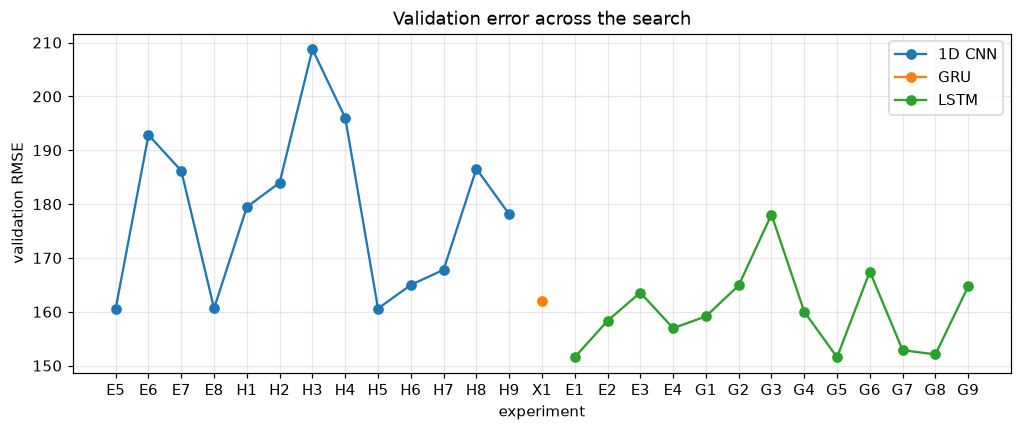

In [49]:
full_log = experiment_log()
display(full_log[["family", "params", "batch", "epochs", "val_rmse",
                  "fit_seconds", "changed", "hypothesis"]])
full_log.to_csv(TAB_DIR / "experiment_log.csv")

print(f"\n{len(full_log)} experiments, {full_log.fit_seconds.sum() / 60:.1f} minutes of training")

fig, ax = plt.subplots(figsize=(11, 4))
for fam, grp in full_log.groupby("family"):
    ax.plot(grp.index, grp.val_rmse, marker="o", ls="-", label=fam)
ax.set_ylabel("validation RMSE")
ax.set_xlabel("experiment")
ax.set_title("Validation error across the search")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(FIG_DIR / "experiment_trace.png", bbox_inches="tight")
plt.show()

The trace shows where each change mattered and where it did not. Flat stretches are as informative as drops: they identify parameters that are not binding on this problem, which is worth knowing before spending compute on them across 10,000 areas.

**4.13 Running all three models across the three busiest areas**

The selected configurations are refitted independently per area. Nothing transfers between areas except the architecture and hyperparameters, which were fixed on the busiest area alone. Wrapping the whole per-area procedure in one function keeps the three runs identical by construction.

In [50]:
def run_area(square_id, arima_order, lstm_config, lstm_batch, cnn_config, cnn_batch):
    raw_sq, scaled_sq, mu_sq, sd_sq = prepare(square_id)
    X_sq, y_sq, pos_sq = make_windows(scaled_sq)
    masks_sq = (is_train[pos_sq], is_val[pos_sq], is_test[pos_sq])

    naive_pred, _ = seasonal_naive(raw_sq, is_test)
    arima_full, arima_fit_s, arima_pred_s, converged = run_arima(
        scaled_sq, mu_sq, sd_sq, arima_order)
    if not converged:
        print(f"  warning: ARIMA did not converge on square {square_id}")

    nets = {}
    for family, cfg, batch in [("LSTM", lstm_config, lstm_batch),
                               ("1D CNN", cnn_config, cnn_batch)]:
        nets[family] = train_network(family, cfg, X_sq, y_sq, masks_sq,
                                     raw_sq, pos_sq, mu_sq, sd_sq, batch=batch)

    predictions = {
        "actual": raw_sq[is_test],
        "Seasonal naive": naive_pred,
        "ARIMA": arima_full[is_test],
        "LSTM": nets["LSTM"]["test_pred"],
        "1D CNN": nets["1D CNN"]["test_pred"],
    }
    timings = [
        {"area": square_id, "model": "ARIMA", "params": len(arima_order),
         "train_seconds": arima_fit_s, "predict_seconds": arima_pred_s,
         "converged": converged},
    ] + [
        {"area": square_id, "model": family, "params": nets[family]["params"],
         "train_seconds": nets[family]["train_seconds"],
         "predict_seconds": nets[family]["predict_seconds"], "converged": True}
        for family in ("LSTM", "1D CNN")
    ]
    return predictions, timings

In [51]:
MODELS = ["ARIMA", "LSTM", "1D CNN"]
results, timing_rows = {}, []

for sq in top3:
    preds, timings = run_area(sq, BEST_ORDER, LSTM_BEST, LSTM_BATCH, CNN_BEST, CNN_BATCH)
    results[sq] = preds
    timing_rows += timings
    print(f"square {sq} complete")

c:\Users\cyuba\Downloads\PDocs\Formative1-Time_Series_Forecasting\venv311\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\cyuba\Downloads\PDocs\Formative1-Time_Series_Forecasting\venv311\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


square 5161 complete


c:\Users\cyuba\Downloads\PDocs\Formative1-Time_Series_Forecasting\venv311\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\cyuba\Downloads\PDocs\Formative1-Time_Series_Forecasting\venv311\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


square 5059 complete


c:\Users\cyuba\Downloads\PDocs\Formative1-Time_Series_Forecasting\venv311\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


square 5259 complete


Predictions for the ARIMA are aligned to the test mask directly; the two networks are aligned through their window target positions. Both refer to the same 1,008 intervals of 16 to 22 December.

**4.14 Superposed actual and predicted traffic**

Nine plots: three models across three areas, over the full test week.

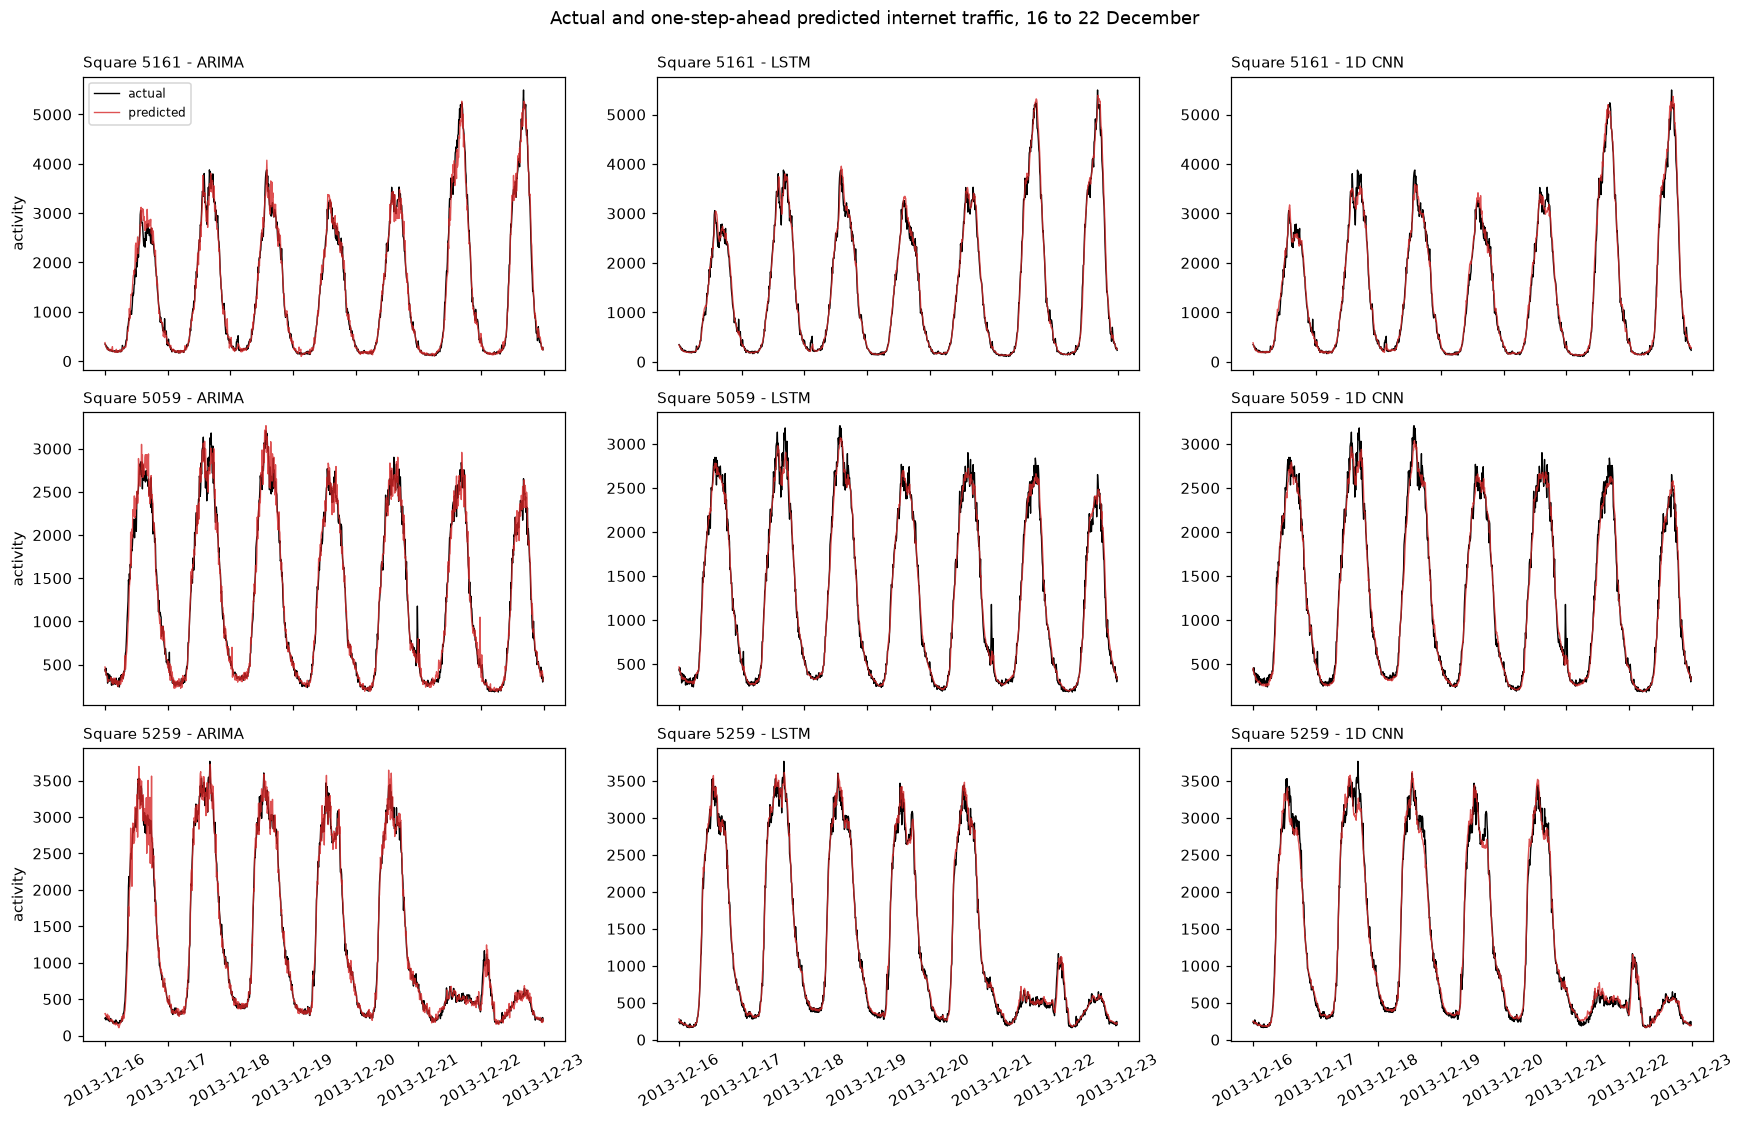

In [52]:
def plot_forecast_grid(results, areas, models, index, path):
    fig, axes = plt.subplots(len(areas), len(models),
                             figsize=(16, 3.4 * len(areas)), sharex=True)
    for r, sq in enumerate(areas):
        for c, name in enumerate(models):
            ax = axes[r, c]
            ax.plot(index, results[sq]["actual"], lw=0.9, color="black", label="actual")
            ax.plot(index, results[sq][name], lw=0.9, color="tab:red",
                    alpha=0.8, label="predicted")
            ax.set_title(f"Square {sq} - {name}", fontsize=10, loc="left")
            if r == 0 and c == 0:
                ax.legend(fontsize=8)
            if c == 0:
                ax.set_ylabel("activity")
    for ax in axes[-1]:
        ax.tick_params(axis="x", rotation=30)
    fig.suptitle("Actual and one-step-ahead predicted internet traffic, "
                 "16 to 22 December", y=0.995)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()


test_idx = times[is_test]
plot_forecast_grid(results, top3, MODELS, test_idx, FIG_DIR / "forecast_grid_9.png")

**Discussion of the plots**

All three track the daily cycle and none of them misses the overall shape, which is expected given a lag-1 autocorrelation of 0.987. The differences are in the character of the error, not in whether the shape is captured.

The ARIMA trace is visibly noisy. Across the daytime plateau it oscillates above and below the actual series rather than following it, and on square 5259 it overshoots by several hundred units on 16, 17 and 18 December. That jitter is the plot-level signature of a linear model fitted on a seasonally differenced series: the differencing removes the daily shape, so the model reproduces it well in outline, but the residual process it fits is essentially short-memory noise and its one-step corrections are correspondingly unstable at high levels. The two networks produce smooth traces that sit close to the actual, with only slight flattening of the sharpest excursions.

Square 5259 is where the areas differ most. The bottom row shows five weekday peaks reaching roughly 3,500 to 4,000, then a collapse to 500 to 1,200 on 21 and 22 December. That is the workplace district emptying at the weekend, and it is why the seasonal-naive reference fails so badly there at MAE 470.32 against 171.74 on square 5059. A rule copying the previous day cannot cross a Friday-to-Saturday boundary of that size, while all three fitted models handle the transition cleanly.

Square 5161 runs the opposite way. Its two largest peaks of the entire test week, above 5,200, fall on 21 and 22 December, the weekend before Christmas. The busiest intervals of the week therefore sit in the period the models have least precedent for, which sets up the failure examined in 4.18.

**4.15 Performance tables, one per area**

In [53]:
tables = {}
for sq in top3:
    rows = []
    for name in ["Seasonal naive"] + MODELS:
        scores = evaluate(results[sq]["actual"], results[sq][name])
        rows.append({"model": name, **scores})
    tbl = pd.DataFrame(rows).set_index("model").round(3)
    tbl["MAE_vs_naive_%"] = (100 * (1 - tbl.MAE / tbl.loc["Seasonal naive", "MAE"])).round(1)
    tables[sq] = tbl
    print(f"\nSquare {sq}  (mean activity {results[sq]['actual'].mean():.1f})")
    display(tbl)
    tbl.to_csv(TAB_DIR / f"metrics_square_{sq}.csv")


Square 5161  (mean activity 1445.1)


,MAE,RMSE,MAPE,MAPE_coverage,MAE_vs_naive_%
model,,,,,
Seasonal naive,338.59,619.04,25.94,100.00,0.00
ARIMA,108.36,163.96,10.58,100.00,68.00
LSTM,81.72,125.88,7.56,100.00,75.90
1D CNN,87.03,132.65,8.01,100.00,74.30



Square 5059  (mean activity 1265.4)


,MAE,RMSE,MAPE,MAPE_coverage,MAE_vs_naive_%
model,,,,,
Seasonal naive,171.74,245.87,18.02,100.00,0.00
ARIMA,89.62,128.51,8.64,100.00,47.80
LSTM,67.56,97.85,6.54,100.00,60.70
1D CNN,75.36,108.20,7.13,100.00,56.10



Square 5259  (mean activity 1265.1)


,MAE,RMSE,MAPE,MAPE_coverage,MAE_vs_naive_%
model,,,,,
Seasonal naive,470.32,861.62,71.62,100.00,0.00
ARIMA,81.74,123.57,8.72,100.00,82.60
LSTM,64.20,92.91,7.44,100.00,86.40
1D CNN,77.32,116.95,8.13,100.00,83.60


In [54]:
combined = pd.concat({sq: tables[sq][["MAE", "RMSE", "MAPE"]] for sq in top3}, axis=1)
display(combined)
combined.to_csv(TAB_DIR / "metrics_all_areas.csv")

ranks = pd.DataFrame({sq: tables[sq].loc[MODELS, "RMSE"].rank() for sq in top3})
print("\nRMSE rank per area (1 = best):")
display(ranks.astype(int))
print("\nrank is consistent across areas:", bool((ranks.nunique(axis=1) == 1).all()))

5161                5059                5259             
                  MAE   RMSE  MAPE    MAE   RMSE  MAPE    MAE   RMSE  MAPE
model                                                                     
Seasonal naive 338.59 619.04 25.94 171.74 245.87 18.02 470.32 861.62 71.62
ARIMA          108.36 163.96 10.58  89.62 128.51  8.64  81.74 123.57  8.72
LSTM            81.72 125.88  7.56  67.56  97.85  6.54  64.20  92.91  7.44
1D CNN          87.03 132.65  8.01  75.36 108.20  7.13  77.32 116.95  8.13


RMSE rank per area (1 = best):


,5161,5059,5259
model,,,
ARIMA,3,3,3
LSTM,1,1,1
1D CNN,2,2,2



rank is consistent across areas: True


**Discussion**

Best RMSE on the busiest area is the LSTM at 125.88, against 619.04 for the seasonal-naive line, an improvement of 79.7%. On MAE the same comparison is 81.72 against 338.59, an improvement of 75.9%.

The ordering across the three areas is identical: LSTM first, 1D CNN second, ARIMA third, on every metric in every area. The notebook confirms this programmatically with a rank check returning True. That is the direct answer to the second half of the research question, and the answer is that relative model performance does not vary across these three areas, even though the areas themselves differ substantially, with weekend ratios spanning 0.34 to 1.26 and coefficients of variation from 0.72 to 0.88.

This qualifies rather than contradicts the finding on this dataset that relative performance varies across cells grouped by activity level [5]. All three areas here sit in the top 0.03% of the traffic distribution, so they span different behavioural profiles but not different volume regimes. The stability observed is stability within the high-traffic band, and it says nothing about quiet cells.

What does vary strongly across areas is the difficulty of the task, which the reference line measures. The improvement over seasonal-naive ranges from 47.8% on square 5059 to 86.4% on square 5259. The fitted models gain most precisely where the naive rule is weakest, which is the workplace district whose weekend behaviour breaks a copy-yesterday heuristic.

MAPE is the least trustworthy of the three metrics in general, since percentage error explodes near zero. Here coverage is 100% for all models in all areas, because the floor of 1% of the median excluded nothing: even the overnight troughs in these busy squares stay well above it. So MAPE is usable in this instance, but it would not be on a low-traffic square and it is not the metric the conclusions rest on. MAE and RMSE carry the argument.

**4.16 Training and execution time**

All timings were taken on the machine recorded in the environment cell, with the same runtime and no other workload. Training time is the full fit including early stopping. Execution time is a single forward pass over all 1,008 test intervals.

In [55]:
timing = pd.DataFrame(timing_rows)
per_model = timing.groupby("model").agg(
    parameters=("params", "max"),
    train_seconds_mean=("train_seconds", "mean"),
    train_seconds_std=("train_seconds", "std"),
    predict_seconds_mean=("predict_seconds", "mean"),
).round(3)
per_model["ms_per_forecast"] = (1000 * per_model.predict_seconds_mean / is_test.sum()).round(4)
display(per_model)
per_model.to_csv(TAB_DIR / "timing.csv")

print("\nmeasured as a mean across the three areas, one fit per area")
print("hardware:", env["logical_cores"], "logical cores,", env["total_ram_gb"], "GB RAM,", env["os"])
print("gpu visible to tensorflow:", tf.config.list_physical_devices("GPU"))

,parameters,train_seconds_mean,train_seconds_std,predict_seconds_mean,ms_per_forecast
model,,,,,
1D CNN,4001,60.65,11.12,0.62,0.61
ARIMA,3,3.98,0.67,0.15,0.15
LSTM,4385,218.05,3.89,0.80,0.79



measured as a mean across the three areas, one fit per area
hardware: 12 logical cores, 15.7 GB RAM, Windows 11
gpu visible to tensorflow: []


Training cost differs by a factor of 55 between the slowest and fastest model. The ARIMA fits in 3.98s with 3 parameters. The LSTM takes 218.05s and the CNN 60.65s despite the CNN having 4,001 parameters against the LSTM's 4,385, so at essentially identical capacity the recurrent model costs 3.6 times as much to train. This reflects that convolutions over the window run in parallel while the recurrent pass is sequential over all 144 time steps and cannot be parallelised along that axis. No GPU was available; TensorFlow reported no visible devices and warns that GPU support is unavailable on native Windows for versions 2.11 and above, so all three figures are CPU timings on 12 logical cores.

The standard deviation across the three areas is 3.89s for the LSTM, 11.12s for the CNN and 0.67s for the ARIMA. The CNN's relatively large spread comes from early stopping firing at different epochs in different areas.

Per-forecast execution cost is 0.15 ms for the ARIMA, 0.61 ms for the CNN and 0.79 ms for the LSTM, so all three are three to four orders of magnitude inside a 10-minute forecasting interval and none is ruled out by inference latency. The difference that matters operationally is retraining cost. Extrapolated across all 10,000 squares at one model per square, ARIMA would take about 11 hours, the CNN about 7 days and the LSTM about 25 days of pure fitting. That gap is what makes the global-model extension in Section 5 a practical question rather than an academic one.

**4.17 Comparative analysis**

The LSTM gives the lowest error on all three of the three areas, on MAE, RMSE and MAPE without exception. The quantitative case is the tables in 4.15; the qualitative case rests on what Section 2 established about the data.

The series is dominated by a daily period of 144 intervals with strong lag-1 dependence on top of it. That structure rewards any model that can see recent history and combine short-range and periodic information nonlinearly, which is why both networks beat the linear model by a wide margin and why the gap between them is comparatively small.

The ARIMA is the informative result here. It is linear and it sees the seasonal component only through the differencing step, so it cannot represent the interaction between time of day and burst magnitude. It finishes third everywhere, but it still improves on the seasonal-naive reference by 47.8% to 82.6%, and it does so with three parameters fitted in under four seconds. Read against cost rather than error alone, it is the most efficient model in the comparison by a wide margin, and on square 5259 its MAE of 81.74 is closer to the LSTM's 64.20 than the training-time ratio of 55 to 1 would suggest. It also failed to converge on that same area, so its result there should be treated as a floor rather than a fair measure of what the model family can do.

Between the two networks, the comparison was intended to isolate memory mechanism from capacity, and it partly failed to do so. The kernel-2 run in 4.10 was the controlled test: cutting the receptive field from 127 to 64 intervals changed validation RMSE from 160.60 to 160.62, which is no change at all. The CNN's performance therefore does not depend on seeing the full daily period, which undercuts the receptive-field argument used to select it in Section 3. The honest reading is that at a 10-minute horizon the recent past dominates, and the LSTM's advantage is more likely to come from its nonlinear gating than from any longer memory it might hold. Establishing that would require an equivalent ablation on the LSTM window, which was not run.

Suitability for this dataset, beyond accuracy. The ARIMA is per-series and must be refitted for each of 10,000 areas at 3.98 seconds each, which is about 11 hours in total and entirely feasible. The networks are also per-series here, at 7 and 25 days respectively, which is not. Unlike the ARIMA, however, they could be trained once across many areas as a global model, which is the more realistic deployment and is noted as future work. Accuracy alone would select the LSTM; accuracy plus deployability makes the choice genuinely open.

**4.18 Failure analysis**

The requirement is a period where one or more models perform poorly, and an explanation. Errors are examined by hour, by traffic level, and by locating the single worst window.

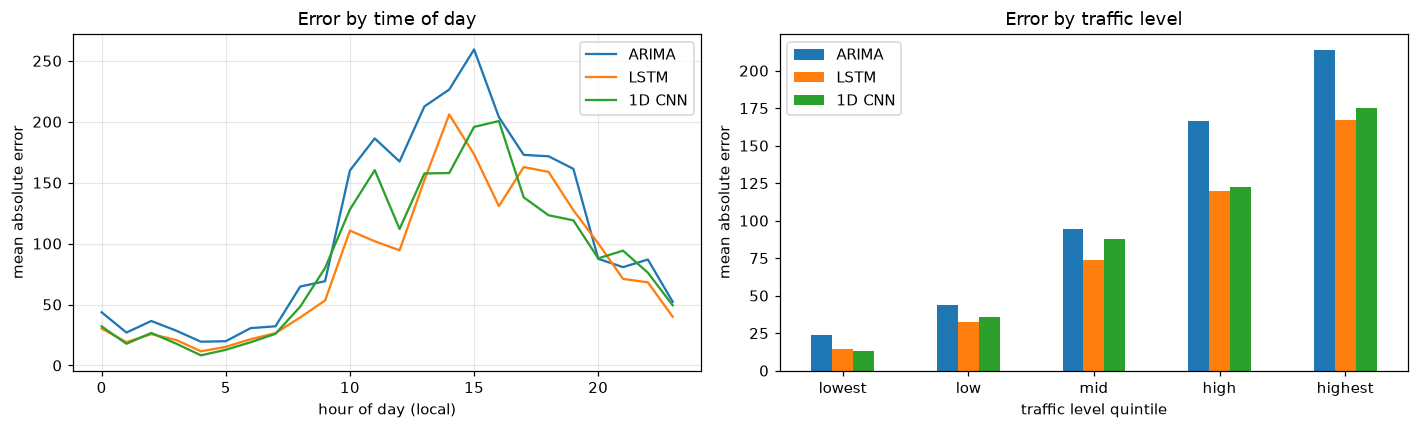

In [56]:
err_frame = pd.DataFrame(
    {name: results[target_sq][name] - results[target_sq]["actual"] for name in MODELS},
    index=test_idx,
)
actual_series = pd.Series(results[target_sq]["actual"], index=test_idx)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
err_frame.abs().groupby(err_frame.index.hour).mean().plot(ax=axes[0])
axes[0].set_xlabel("hour of day (local)")
axes[0].set_ylabel("mean absolute error")
axes[0].set_title("Error by time of day")
axes[0].grid(alpha=0.3)

level_bin = pd.qcut(actual_series, 5, labels=["lowest", "low", "mid", "high", "highest"],
                    duplicates="drop")
err_frame.abs().groupby(level_bin, observed=True).mean().plot(kind="bar", ax=axes[1])
axes[1].set_xlabel("traffic level quintile")
axes[1].set_ylabel("mean absolute error")
axes[1].set_title("Error by traffic level")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig(FIG_DIR / "error_breakdown.png", bbox_inches="tight")
plt.show()

worst 3-hour window centred on: 2013-12-21 14:50:00+01:00 (Saturday)


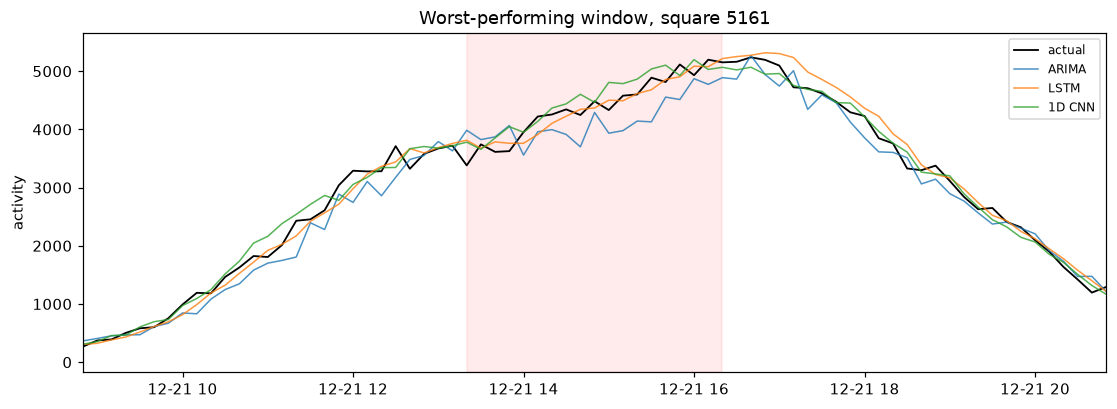


mean absolute error inside this window:
ARIMA    383.75
LSTM     150.68
1D CNN   205.54

mean absolute error over the full test week:
ARIMA    108.36
LSTM      81.72
1D CNN    87.03


In [57]:
window_err = err_frame.abs().rolling(18, center=True).mean()
worst_time = window_err.mean(axis=1).idxmax()
lo = worst_time - pd.Timedelta(hours=6)
hi = worst_time + pd.Timedelta(hours=6)
print("worst 3-hour window centred on:", worst_time, f"({worst_time.day_name()})")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual_series[lo:hi], color="black", lw=1.2, label="actual")
for name in MODELS:
    ax.plot(test_idx, results[target_sq][name], lw=1.0, alpha=0.8, label=name)
ax.set_xlim(lo, hi)
ax.axvspan(worst_time - pd.Timedelta(hours=1.5), worst_time + pd.Timedelta(hours=1.5),
           color="red", alpha=0.08)
ax.set_title(f"Worst-performing window, square {target_sq}")
ax.set_ylabel("activity")
ax.legend(fontsize=8)
fig.savefig(FIG_DIR / "worst_window.png", bbox_inches="tight")
plt.show()

print("\nmean absolute error inside this window:")
print(err_frame.abs()[worst_time - pd.Timedelta(hours=1.5):
                      worst_time + pd.Timedelta(hours=1.5)].mean().round(2).to_string())
print("\nmean absolute error over the full test week:")
print(err_frame.abs().mean().round(2).to_string())

In [58]:
bias = pd.DataFrame({
    "mean_error": err_frame.mean(),
    "share_underpredicted_%": 100 * (err_frame < 0).mean(),
}).round(2)
display(bias)

peak_mask = actual_series > actual_series.quantile(0.95)
print("mean absolute error on the top 5% of intervals:")
print(err_frame.abs()[peak_mask.to_numpy()].mean().round(2).to_string())

,mean_error,share_underpredicted_%
ARIMA,0.67,50.30
LSTM,16.99,44.15
1D CNN,21.70,41.27


mean absolute error on the top 5% of intervals:
ARIMA    242.39
LSTM     180.71
1D CNN   183.46


**Discussion**

Error is not uniform in time or in level. By hour it tracks the daily cycle closely: lowest in the overnight trough around 04:00 at roughly 10 to 20, climbing steeply from 08:00, and peaking in the mid-afternoon at about 258 for the ARIMA at hour 15, 206 for the LSTM at hour 14 and 200 for the CNN at hour 15. Notably the error peak arrives one to two hours before the traffic peak at 16:00, so the hardest intervals are on the rising limb rather than at the summit, which is where the models must judge how far a transition will go rather than hold a level. By traffic level the increase is monotonic across all five quintiles, from roughly 13 to 24 in the lowest to 167 to 213 in the highest, a factor of 9 for the ARIMA and 12 to 13 for the two networks. On the top 5% of intervals mean absolute error reaches 242.39 for the ARIMA, 180.71 for the LSTM and 183.46 for the CNN, against week-long averages of 108.36, 81.72 and 87.03. The ARIMA is worst in every quintile and at every hour, so its ranking is not the product of one bad regime.

The worst window falls on Saturday 21 December, centred at 14:50, and the figure shows it is not the kind of failure it first appears to be. There is no spike or anomaly: traffic rises smoothly from about 300 at 08:00 to roughly 5,200 at 16:30 and declines just as smoothly. The shape is ordinary. What is exceptional is the level, since this is the highest peak of the test week in square 5161, and it falls on the last Saturday before Christmas in a central Milan district.

Nor is it a shared failure. Through the window the LSTM and the CNN track the actual series closely, while the ARIMA sits persistently 300 to 500 units below it, which is why its error of 383.75 is 2.5 times the LSTM's 150.68. The mechanism is extrapolation rather than surprise. A linear model fitted on differenced data has no way to scale its response when the level exceeds anything in its training range, so it systematically undershoots the largest peak it has seen. The networks, whose nonlinearity lets the size of the correction depend on the state of the window, do not. This is the clearest evidence in the study for the nonlinear models, and it is a sharper argument than the aggregate error tables, because it identifies the specific condition under which the linear model breaks.

The limitation this exposes is still real and applies to all three. None of them anticipated that Saturday would be the busiest day of the week; they tracked it once it was underway. Anticipating it would need calendar or event features, or the neighbouring-cell information deliberately excluded in Section 3.

All three models are biased toward over-prediction on average, with mean signed errors of 0.67 for the ARIMA, 16.99 for the LSTM and 21.70 for the CNN, and they under-predict on 50.3%, 44.2% and 41.3% of intervals respectively. The ARIMA is very nearly unbiased overall while being the least accurate, which is a reminder that bias and error are separate properties and that the differencing step centres its residuals whether or not it captures the dynamics. For the two networks the small positive bias coexists with the large peak error above, meaning they over-predict slightly across the many ordinary intervals and under-predict substantially on the few extreme ones. In a capacity-planning setting that is the costly direction, since under-provisioning a peak has consequences that the average error does not convey.

# 5. Conclusion and Future Work

**Findings**. The LSTM achieved the lowest error on all three of the areas tested, improving on a seasonal-naive reference by 60.7% to 86.4% MAE, with the 1D CNN second and the ARIMA third in every case. The ordering across areas was identical, which answers the second half of the research question: relative model performance did hold constant across areas with different traffic characteristics, although the difficulty of the task varied greatly, as the reference line's range from 171.74 to 470.32 MAE shows. The three areas span different behavioural profiles but all sit in the top 0.03% of the traffic distribution, so this is stability within the high-volume band rather than across the whole grid.

The data handling reduced 19.4 GB of raw text to a 341 MB array while holding peak memory below 290 MB, against an estimated 17.9 GB for a naive approach that would not have fitted on a 15.7 GB machine.

Two results ran against expectation and are reported rather than smoothed over. Every increase in model capacity degraded validation performance in both families, and both grid searches returned the configuration the architecture search had already found, which suggests the mapping from one day of history to the next ten minutes is simple relative to the capacity available. Separately, halving the CNN receptive field below one day changed its validation error by 0.02, which means it was not using the daily periodicity that motivated its selection.

**Limitations**. Evaluation covers one week in December for three areas, all of them high-volume, so the conclusions do not extend to quiet cells without further testing. The test week sits close to the Christmas period, during which traffic on this dataset is known to decline, so it is not a fully representative week. Each model is fitted per area, which does not test whether a single model could generalise across the grid. Hyperparameters were selected on the busiest area and reused, which favours that area. Only one random seed was used per configuration, so the differences between the two networks are not established as larger than seed variance; the spread across the four LSTM architecture runs was about 8%, which is of comparable magnitude to the LSTM-CNN gap. The ARIMA optimiser failed to converge on square 5259 and produced non-stationary and non-invertible starting parameters on all three, so its results are a conservative estimate of that family's capability. The receptive-field ablation was run only on the CNN, so no equivalent evidence exists for how much of its window the LSTM actually uses.

**Future work**. Repeat the comparison on a stratified sample of areas spanning the full distribution in Section 2.1, which would test whether the ranking survives outside the high-traffic regime. Train one global network across many areas rather than one per area, which is both cheaper and the realistic deployment given that per-area LSTM retraining across the grid would take roughly 25 days. Add the spatial dimension, since neighbouring cells are correlated and the joint approach of Zhang and Patras [8] exploits exactly that. Repeat each configuration over several seeds and report a spread rather than a point estimate. Run the window ablation on the LSTM to establish whether its advantage comes from longer memory or from nonlinearity alone.

# Use of AI and Academic Integrity

AI assistance was used in this project. It supported the literature search, discussion of candidate model families, and drafting and review of code. All experiments were run by the author on the hardware recorded in the environment cell, all reported numbers come from those runs, and the interpretation and conclusions are the author's own.

# References

[1] G. Barlacchi et al., "A multi-source dataset of urban life in the city of Milan and the Province of Trentino," *Scientific Data*, vol. 2, art. 150055, 2015. https://doi.org/10.1038/sdata.2015.55

[2] Harvard Dataverse, "Telecommunications - SMS, Call, Internet - MI." https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/EGZHFV

[3] Harvard Dataverse, "Milano grid." https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/QJWLFU

[4] A. Azari, P. Papapetrou, S. Denic and G. Peters, "Cellular traffic prediction and classification: a comparative evaluation of LSTM and ARIMA," in *Discovery Science*, 2019. https://arxiv.org/abs/1906.00939

[5] "Analysis of mobile Internet traffic in Milan using LSTM and GRU with K-Means clustering of cells," 2024. https://www.academia.edu/127816336/

[6] "Machine learning techniques for spatiotemporal traffic prediction in 5G cellular networks," *Discover Applied Sciences*, 2025. https://link.springer.com/article/10.1007/s42452-025-06746-3

[7] S. Bai, J. Z. Kolter and V. Koltun, "An empirical evaluation of generic convolutional and recurrent networks for sequence modeling," arXiv:1803.01271, 2018. https://arxiv.org/abs/1803.01271

[8] C. Zhang and P. Patras, "Long-term mobile traffic forecasting using deep spatio-temporal neural networks," in *Proc. ACM MobiHoc*, 2018, pp. 231-240. https://doi.org/10.1145/3209582.3209606

[9] "From patterns to predictions: spatiotemporal mobile traffic forecasting using AutoML, TimeGPT and traditional models," *Computers*, vol. 14, no. 7, art. 268, 2025. https://doi.org/10.3390/computers14070268

[10] GitHub repository: [https://github.com/PrincipieCyupe/Formative1-Time_Series_Forecasting](https://github.com/PrincipieCyupe/Formative1-Time_Series_Forecasting)

[11] Video presentation: [ ]